In [1]:
import warnings
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.optimize import minimize
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from IPython.display import display
from arch import arch_model

from quantfinlab.options.diagnostics import build_atm_iv_panel_from_option_quotes

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

palette = [
    "#006d77", "#e29578", "#264653", "#2a9d8f", "#e9c46a",
    "#f4a261", "#d62828", "#457b9d", "#7b2cbf", "#6a994e",
]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (7, 3.2),
    "figure.dpi": 160,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

seed = 7
np.random.seed(seed)

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data").exists() else cwd.parent
data_dir = project_root / "data"

option_path = data_dir / "spx_options_chain_202201_202312.parquet"
rate_path = data_dir / "par-yield-curve-rates-1990-2026.csv"
spx_path = data_dir / "spx_daily_yfinance.csv"

horizons = (1, 5, 10, 21, 42, 63)
annualization = 252
calender_days = 365.25
eps = 1e-12


In [2]:
required_files = [option_path, rate_path, spx_path]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required Project 5 data files: " + ", ".join(missing))

chain_cols = [
    "quote_date", "quote_readtime", "expire_date", "underlying_last",
    "strike", "c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume",
]
df_chain = pd.read_parquet(option_path, columns=chain_cols)
df_rates = pd.read_csv(rate_path)
df_spx_raw = pd.read_csv(spx_path)

for col in ["quote_date", "quote_readtime", "expire_date"]:
    df_chain[col] = pd.to_datetime(df_chain[col], errors="coerce")
df_chain["trade_date"] = df_chain["quote_date"].dt.normalize()
df_chain["expiry_datetime"] = df_chain["expire_date"].dt.normalize()
df_chain["quote_datetime"] = pd.to_datetime(df_chain["quote_readtime"], errors="coerce")
df_chain["dte_calendar"] = (df_chain["expiry_datetime"] - df_chain["trade_date"]).dt.total_seconds() / 86400.0
for col in ["underlying_last", "strike", "c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume"]:
    df_chain[col] = pd.to_numeric(df_chain[col], errors="coerce")

def clean_yfinance_price_frame(raw, price_name, include_dividend=False):
    data = raw.copy()
    data.columns = [str(c).strip().lower().replace(" ", "_") for c in data.columns]
    if "date" not in data.columns:
        raise ValueError(f"{price_name} file must contain a date column")
    data["trade_date"] = pd.to_datetime(data["date"], errors="coerce").dt.normalize()
    price_col = "adj_close" if "adj_close" in data.columns else "close"
    data[price_col] = pd.to_numeric(data[price_col], errors="coerce")
    out = data[["trade_date", price_col]].rename(columns={price_col: price_name})
    if include_dividend:
        div_col = "dividends" if "dividends" in data.columns else None
        out["dividend"] = pd.to_numeric(data[div_col], errors="coerce").fillna(0.0) if div_col else 0.0
    return out.dropna(subset=["trade_date", price_name]).sort_values("trade_date").drop_duplicates("trade_date", keep="last")

df_spx = clean_yfinance_price_frame(df_spx_raw, "spx_close")
df_spx["spx_ret"] = np.log(df_spx["spx_close"] / df_spx["spx_close"].shift(1))
df_market = df_spx.sort_values("trade_date").reset_index(drop=True)

ret = df_market["spx_ret"].to_numpy(dtype=float)
for h in horizons:
    rv_sum = np.full(len(df_market), np.nan, dtype=float)
    for i in range(len(df_market) - h):
        window = ret[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            rv_sum[i] = float(np.sum(window * window))
    df_market[f"realized_var_sum_fwd_{h}"] = rv_sum
    df_market[f"realized_var_ann_fwd_{h}"] = annualization / h * rv_sum
    df_market[f"realized_vol_ann_fwd_{h}"] = np.sqrt(np.clip(df_market[f"realized_var_ann_fwd_{h}"], 0, None))

display(pd.DataFrame({
    "metric": ["raw_option_rows", "option_dates", "option_expiries", "market_dates", "return_start", "return_end"],
    "value": [
        int(len(df_chain)),
        int(df_chain["trade_date"].nunique()),
        int(df_chain["expiry_datetime"].nunique()),
        int(len(df_market)),
        str(df_market["trade_date"].min().date()),
        str(df_market["trade_date"].max().date()),
    ],
}))
display(df_market.head())


,metric,value
0,raw_option_rows,4100693
1,option_dates,505
2,option_expiries,524
3,market_dates,24653
4,return_start,1927-12-30
5,return_end,2026-02-24


,trade_date,spx_close,spx_ret,realized_var_sum_fwd_1,realized_var_ann_fwd_1,realized_vol_ann_fwd_1,realized_var_sum_fwd_5,realized_var_ann_fwd_5,realized_vol_ann_fwd_5,realized_var_sum_fwd_10,...,realized_vol_ann_fwd_10,realized_var_sum_fwd_21,realized_var_ann_fwd_21,realized_vol_ann_fwd_21,realized_var_sum_fwd_42,realized_var_ann_fwd_42,realized_vol_ann_fwd_42,realized_var_sum_fwd_63,realized_var_ann_fwd_63,realized_vol_ann_fwd_63
0,1927-12-30,17.660000,NaN,0.000032,0.008035,0.089636,0.000252,0.012689,0.112647,0.000672,...,0.130159,0.001175,0.014097,0.118731,0.001975,0.011852,0.108867,0.003948,0.015793,0.125670
1,1928-01-03,17.760000,0.005647,0.000005,0.001281,0.035795,0.000275,0.013884,0.117832,0.000641,...,0.127068,0.001148,0.013777,0.117375,0.002183,0.013100,0.114454,0.003950,0.015800,0.125698
2,1928-01-04,17.719999,-0.002255,0.000093,0.023418,0.153030,0.000272,0.013695,0.117026,0.000641,...,0.127095,0.001175,0.014104,0.118761,0.002210,0.013262,0.115163,0.003947,0.015790,0.125657
3,1928-01-05,17.549999,-0.009640,0.000039,0.009838,0.099188,0.000226,0.011406,0.106798,0.000596,...,0.122560,0.001255,0.015058,0.122712,0.002144,0.012861,0.113408,0.004012,0.016049,0.126684
4,1928-01-06,17.660000,0.006248,0.000083,0.020874,0.144479,0.000227,0.011424,0.106882,0.000590,...,0.121929,0.001224,0.014689,0.121197,0.002116,0.012697,0.112680,0.003977,0.015910,0.126134


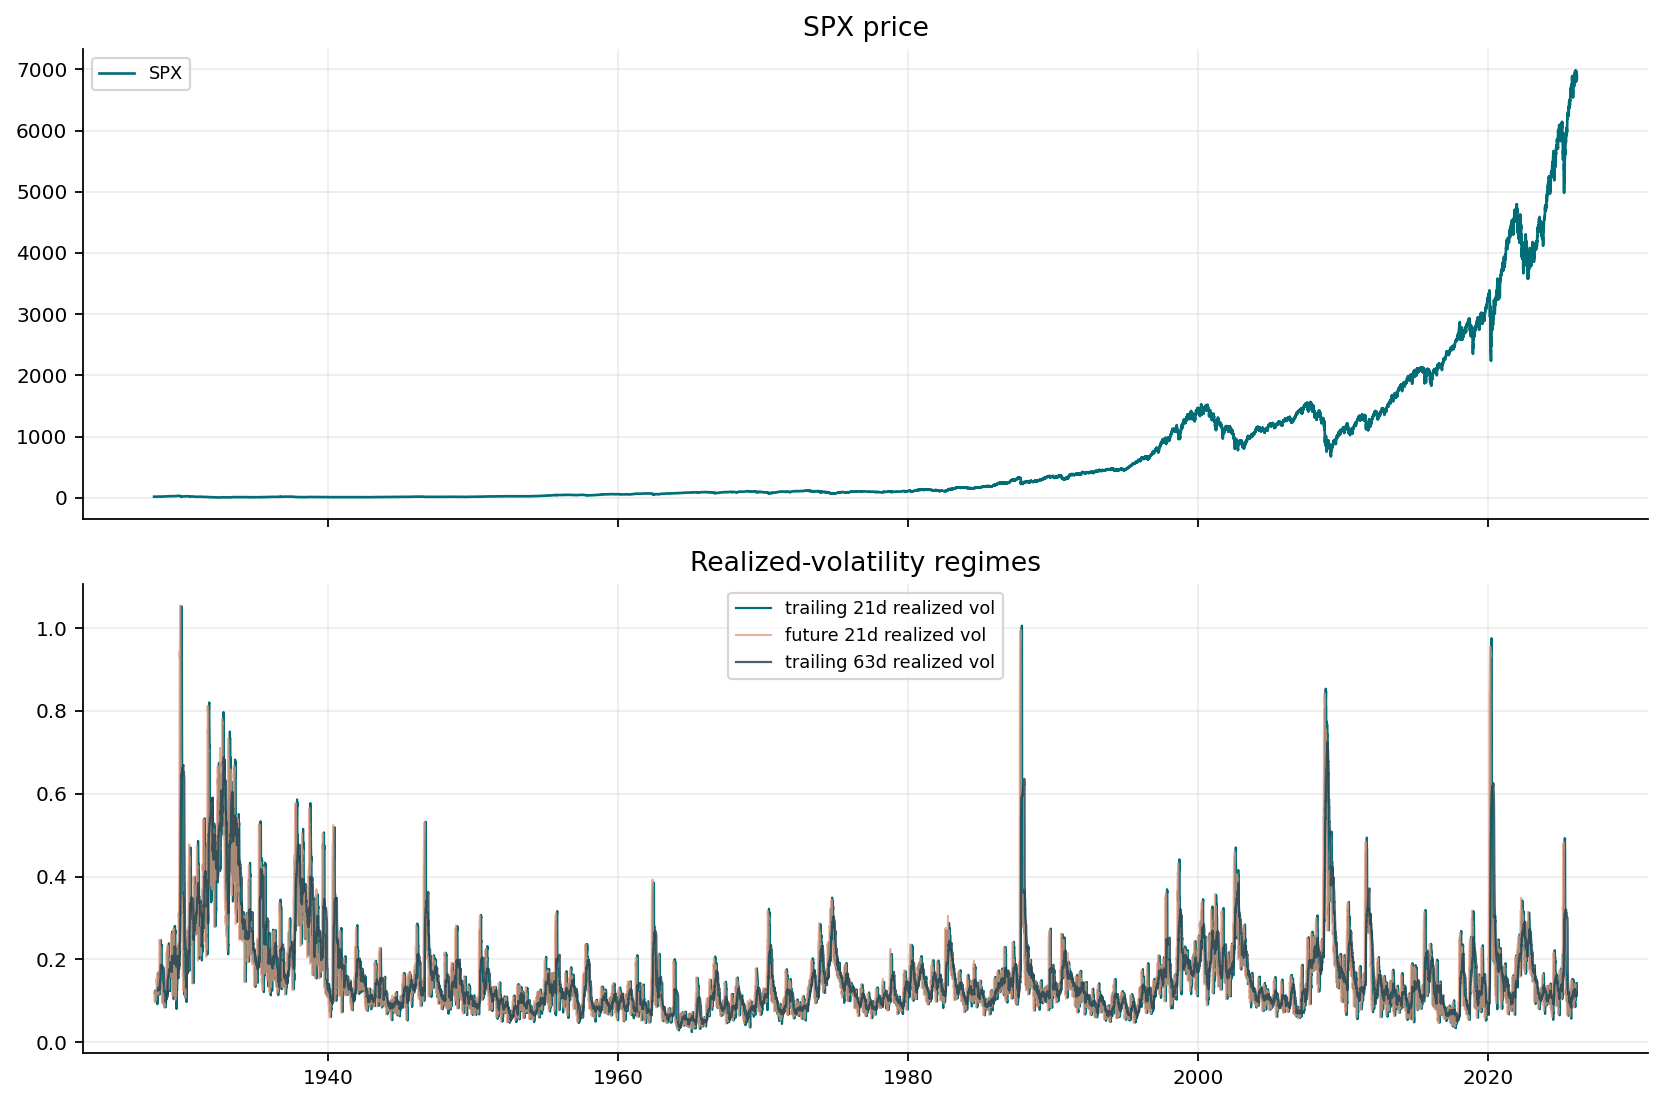

In [3]:
rv_windows = [10, 21, 42, 63, 84, 126]
for w in rv_windows:
    df_market[f"rv_trailing_{w}"] = df_market["spx_ret"].rolling(w).std() * np.sqrt(annualization)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True)
axes[0].plot(df_market["trade_date"], df_market["spx_close"], lw=1.2, label="SPX")
axes[0].set_title("SPX price")
axes[0].legend(loc="best")

axes[1].plot(df_market["trade_date"], df_market["rv_trailing_21"], lw=1.0, label="trailing 21d realized vol")
axes[1].plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.9, alpha=0.75, label="future 21d realized vol")
axes[1].plot(df_market["trade_date"], df_market["rv_trailing_63"], lw=1.0, alpha=0.85, label="trailing 63d realized vol")
axes[1].set_title("Realized-volatility regimes")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


In [4]:
t0 = time.time()
iv_panel_all = build_atm_iv_panel_from_option_quotes(
    df_chain,
    rates=df_rates,
    min_dte=7,
    max_dte=120,
    moneyness_range=(0.85, 1.15),
    max_relative_spread=0.20,
    closest_atm_pairs=25,
    min_pairs_per_expiry=10,
    solver="lbr_lite",
    engine="auto",
    underlying_default="SPX")

print(f"ATM IV panel build time: {time.time() - t0:,.1f}s")
print("IV solver engine:", iv_panel_all.attrs.get("iv_engine", "unknown"))

iv_cleaning_report = iv_panel_all.attrs.get("cleaning_report", pd.DataFrame())
display(iv_cleaning_report)
if iv_panel_all.empty:
    raise RuntimeError("The Project 4 IV wrapper returned an empty ATM IV panel.")

iv_panel_all["date"] = pd.to_datetime(iv_panel_all["date"], errors="coerce").dt.normalize()
iv_panel_all["expiry"] = pd.to_datetime(iv_panel_all["expiry"], errors="coerce").dt.normalize()
iv_panel_all["dte_calendar"] = pd.to_numeric(iv_panel_all["dte_calendar"], errors="coerce")
iv_panel_all["dte_trading"] = pd.to_numeric(iv_panel_all["dte_trading"], errors="coerce")
iv_panel_all["atm_iv_mid"] = pd.to_numeric(iv_panel_all["atm_iv_mid"], errors="coerce")
if iv_panel_all["atm_iv_mid"].dropna().median() > 2.0:
    for col in ["atm_iv_bid", "atm_iv_mid", "atm_iv_ask"]:
        if col in iv_panel_all:
            iv_panel_all[col] = iv_panel_all[col] / 100.0

iv_30d_daily = (
    iv_panel_all[(iv_panel_all["dte_calendar"] >= 21) & (iv_panel_all["dte_calendar"] <= 45)]
    .assign(dte_score=lambda x: (x["dte_calendar"] - 30.0).abs())
    .sort_values(["date", "dte_score", "quote_quality_score"])
    .groupby("date", as_index=False)
    .head(1)
    .drop(columns=["dte_score"], errors="ignore")
    .reset_index(drop=True))

display(pd.DataFrame({
    "metric": ["all_atm_rows", "daily_30d_rows", "first_date", "last_date", "median_atm_iv", "median_dte_calendar"],
    "value": [
        int(len(iv_panel_all)),
        int(len(iv_30d_daily)),
        str(iv_30d_daily["date"].min().date()),
        str(iv_30d_daily["date"].max().date()),
        float(iv_30d_daily["atm_iv_mid"].median()),
        float(iv_30d_daily["dte_calendar"].median())]}))


ATM IV panel build time: 82.0s
IV solver engine: numba


,step,rows,removed
0,raw wide rows,4100693,NaN
1,valid call/put pair quotes,3714637,"386,056.000000"
2,relative spread filter,3222722,"491,915.000000"
3,DTE filter,1959161,"1,263,561.000000"
4,moneyness filter,1606418,"352,743.000000"
5,near-ATM pair preselection,310639,"1,295,779.000000"
6,liquid expiry slices,310639,0.000000
7,long-form raw rows,621278,0.000000
8,long-form after schema normalization,621278,0.000000
9,long-form after positive price filter,621278,0.000000


,metric,value
0,all_atm_rows,12426
1,daily_30d_rows,505
2,first_date,2022-01-03
3,last_date,2023-12-29
4,median_atm_iv,0.181915
5,median_dte_calendar,30.000000


In [5]:
returns_series = df_market.loc[df_market["spx_ret"].notna(), ["trade_date", "spx_ret"]].copy().reset_index(drop=True)
ret_pct = 100.0 * returns_series["spx_ret"].to_numpy(dtype=float)

def garch_backcast(resids, decay=0.94, horizon=75):
    x = np.asarray(resids, dtype=float) ** 2
    n = min(len(x), horizon)
    if n == 0:
        return 1.0
    w = decay ** np.arange(n)
    w = w / w.sum()
    return float(np.sum(w * x[:n][::-1]))

def garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=None):
    eps = np.asarray(returns_pct, dtype=float)
    n = len(eps)
    sigma2 = np.empty(n, dtype=float)
    if backcast is None:
        backcast = garch_backcast(eps)
    sigma2[0] = max(float(backcast), 1e-8)
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        sigma2[t] = max(sigma2[t], 1e-10)
    return sigma2

def garch11_negloglik_normal(params, returns_pct, backcast=None):
    omega, alpha, beta = [float(x) for x in params]
    if omega <= 0.0 or alpha < 0.0 or beta < 0.0 or alpha + beta >= 0.999:
        return 1e16
    sigma2 = garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=backcast)
    ll = -0.5 * (np.log(2.0 * np.pi) + np.log(sigma2) + (returns_pct ** 2) / sigma2)
    value = -float(np.sum(ll))
    return value if np.isfinite(value) else 1e16

def garch11_multi_horizon_variance(last_sigma2, last_eps, omega, alpha, beta, horizons):
    horizons = sorted(set(int(h) for h in horizons))
    out = {}
    h1 = omega + alpha * float(last_eps) ** 2 + beta * float(last_sigma2)
    out[1] = h1
    prev = h1
    for h in range(2, max(horizons) + 1):
        prev = omega + (alpha + beta) * prev
        out[h] = prev
    return {h: out[h] for h in horizons}

def fit_manual_garch11_normal(returns_pct):
    y = np.asarray(returns_pct, dtype=float)
    y = y[np.isfinite(y)]
    backcast = garch_backcast(y)
    var0 = max(float(np.var(y, ddof=1)), 1e-6)
    starts = []
    for alpha0, beta0 in [(0.05, 0.90), (0.08, 0.90), (0.10, 0.85), (0.03, 0.95), (0.12, 0.80)]:
        if alpha0 + beta0 < 0.999:
            starts.append(np.array([max((1.0 - alpha0 - beta0) * var0, 1e-8), alpha0, beta0], dtype=float))
    bounds = [(1e-12, 100.0 * var0), (1e-8, 0.999), (1e-8, 0.999)]
    cons = [{"type": "ineq", "fun": lambda x: 0.999 - x[1] - x[2]}]
    best = None
    for x0 in starts:
        try:
            res = minimize(
                garch11_negloglik_normal,
                x0=x0,
                args=(y, backcast),
                method="SLSQP",
                bounds=bounds,
                constraints=cons,
                options={"maxiter": 2000, "ftol": 1e-12})
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass
    if best is None:
        raise RuntimeError("manual GARCH fit failed")
    omega, alpha, beta = [float(v) for v in best.x]
    sigma2 = garch11_filter_backcast(y, omega, alpha, beta, backcast=backcast)
    std_resid = y / np.sqrt(np.clip(sigma2, 1e-12, None))
    ll = -garch11_negloglik_normal([omega, alpha, beta], y, backcast)
    n = len(y)
    k = 3
    return {
        "success": bool(best.success),
        "message": str(best.message),
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "persistence": alpha + beta,
        "backcast": backcast,
        "sigma2": sigma2,
        "std_resid": std_resid,
        "loglik": ll,
        "aic": 2.0 * k - 2.0 * ll,
        "bic": math.log(n) * k - 2.0 * ll,
        "unc_var": omega / max(1.0 - alpha - beta, 1e-8)}

manual_fit = fit_manual_garch11_normal(ret_pct)
am_manual_check = arch_model(ret_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="normal", rescale=False)
res_manual_check = am_manual_check.fit(disp="off", show_warning=False)

display(pd.DataFrame([
    
    {"model": "manual_garch11_normal",
    "success": manual_fit["success"],
    "omega": manual_fit["omega"],
    "alpha": manual_fit["alpha"],
    "beta": manual_fit["beta"],
    "persistence": manual_fit["persistence"],
    "unc_var_pct2": manual_fit["unc_var"],
    "aic": manual_fit["aic"],
    "bic": manual_fit["bic"]},
    
    {"model": "arch_garch11_normal",
    "success": True,
    "omega": float(res_manual_check.params.get("omega", np.nan)),
    "alpha": float(res_manual_check.params.get("alpha[1]", np.nan)),
    "beta": float(res_manual_check.params.get("beta[1]", np.nan)),
    "persistence": float(res_manual_check.params.get("alpha[1]", np.nan) + res_manual_check.params.get("beta[1]", np.nan)),
    "unc_var_pct2": float(res_manual_check.params.get("omega", np.nan) / max(1.0 - res_manual_check.params.get("alpha[1]", np.nan) - res_manual_check.params.get("beta[1]", np.nan), 1e-8)),
    "aic": float(res_manual_check.aic),
    "bic": float(res_manual_check.bic)}]))


,model,success,omega,alpha,beta,persistence,unc_var_pct2,aic,bic
0,manual_garch11_normal,True,0.010925,0.095796,0.899325,0.995121,2.239160,"65,498.576815","65,522.914655"
1,arch_garch11_normal,True,0.010923,0.095777,0.899349,0.995127,2.241470,"65,498.126263","65,522.464103"


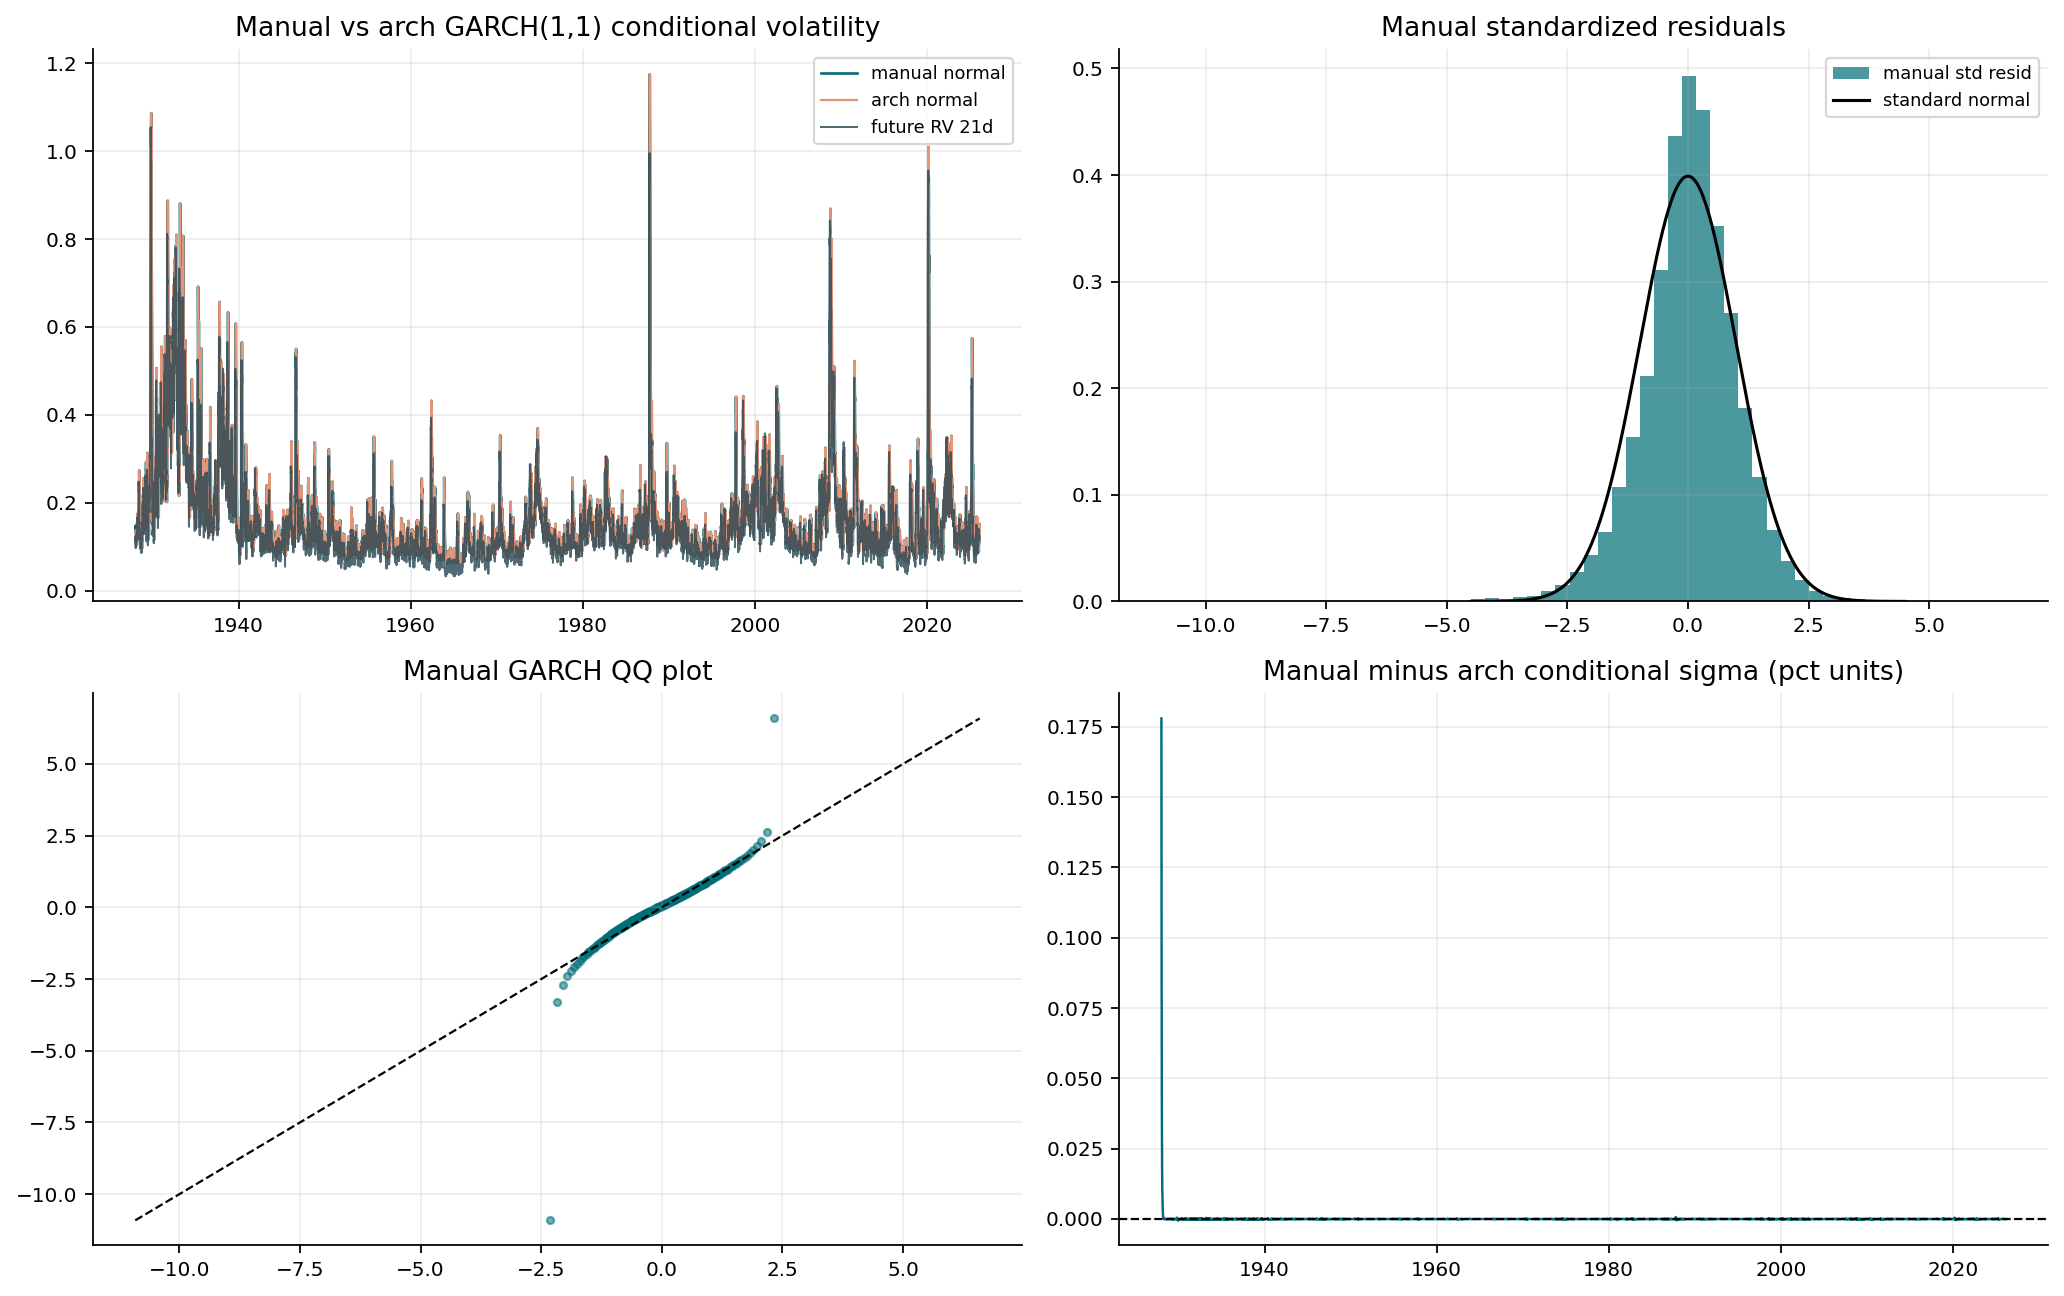

,metric,value
0,manual_arch_param_abs_diff_omega,0.000001
1,manual_arch_param_abs_diff_alpha,0.000019
2,manual_arch_param_abs_diff_beta,0.000024
3,manual_arch_sigma_corr,0.999991


In [6]:
manual_dates = returns_series["trade_date"].reset_index(drop=True)
arch_cond_vol = np.asarray(res_manual_check.conditional_volatility, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.2))
axes[0, 0].plot(manual_dates, np.sqrt(annualization) * np.sqrt(manual_fit["sigma2"]) / 100.0, lw=1.2, label="manual normal")
axes[0, 0].plot(manual_dates, np.sqrt(annualization) * arch_cond_vol / 100.0, lw=1.0, label="arch normal")
axes[0, 0].plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.9, alpha=0.8, label="future RV 21d")
axes[0, 0].set_title("Manual vs arch GARCH(1,1) conditional volatility")
axes[0, 0].legend(loc="best")

axes[0, 1].hist(manual_fit["std_resid"], bins=60, alpha=0.70, density=True, label="manual std resid")
x = np.linspace(-4.5, 4.5, 300)
axes[0, 1].plot(x, norm.pdf(x), lw=1.4, c="black", label="standard normal")
axes[0, 1].set_title("Manual standardized residuals")
axes[0, 1].legend(loc="best")

q_grid = np.linspace(0.01, 0.99, 200)
norm_q = norm.ppf(q_grid)
std_resid_manual = np.sort(pd.Series(manual_fit["std_resid"]).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float))
idx = np.linspace(0, len(std_resid_manual) - 1, len(norm_q)).astype(int)
axes[1, 0].scatter(norm_q, std_resid_manual[idx], s=10, alpha=0.55)
lo = min(norm_q.min(), std_resid_manual[idx].min())
hi = max(norm_q.max(), std_resid_manual[idx].max())
axes[1, 0].plot([lo, hi], [lo, hi], ls="--", lw=1.0, c="black")
axes[1, 0].set_title("Manual GARCH QQ plot")

sigma_diff = np.sqrt(manual_fit["sigma2"]) - arch_cond_vol
axes[1, 1].plot(manual_dates, sigma_diff, lw=1.1)
axes[1, 1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1, 1].set_title("Manual minus arch conditional sigma (pct units)")
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"metric": "manual_arch_param_abs_diff_omega", "value": abs(manual_fit["omega"] - float(res_manual_check.params.get("omega", np.nan)))},
    {"metric": "manual_arch_param_abs_diff_alpha", "value": abs(manual_fit["alpha"] - float(res_manual_check.params.get("alpha[1]", np.nan)))},
    {"metric": "manual_arch_param_abs_diff_beta", "value": abs(manual_fit["beta"] - float(res_manual_check.params.get("beta[1]", np.nan)))},
    {"metric": "manual_arch_sigma_corr", "value": float(np.corrcoef(np.sqrt(manual_fit["sigma2"]), arch_cond_vol)[0, 1])},
]))


,model,loglik,aic,bic,omega,alpha1,alpha2,gamma1,beta1,beta2,nu
0,gjr11_student,"-31,693.245793","63,396.491587","63,437.054653",0.011826,0.028557,NaN,0.113452,0.908128,NaN,6.174988
1,egarch11_student,"-31,877.150130","63,762.300259","63,794.750713",0.007495,0.171965,NaN,NaN,0.990556,NaN,5.756719
2,garch11_student,"-31,890.220232","63,788.440463","63,820.890917",0.008563,0.083748,NaN,NaN,0.912156,NaN,5.833311
3,garch22_student,"-31,888.894940","63,789.789881","63,838.465560",0.009412,0.093659,0.000000,NaN,0.761765,0.140058,5.851436
4,gjr11_normal,"-32,521.033233","65,050.066466","65,082.516919",0.012845,0.037511,NaN,0.098231,0.905648,NaN,NaN
5,garch22_normal,"-32,734.029997","65,478.059994","65,518.623061",0.012867,0.117864,0.000000,NaN,0.586279,0.290243,NaN
6,garch11_normal,"-32,746.063132","65,498.126263","65,522.464103",0.010923,0.095777,NaN,NaN,0.899349,NaN,NaN
7,egarch11_normal,"-32,775.229984","65,556.459968","65,580.797808",0.009028,0.200920,NaN,NaN,0.987354,NaN,NaN


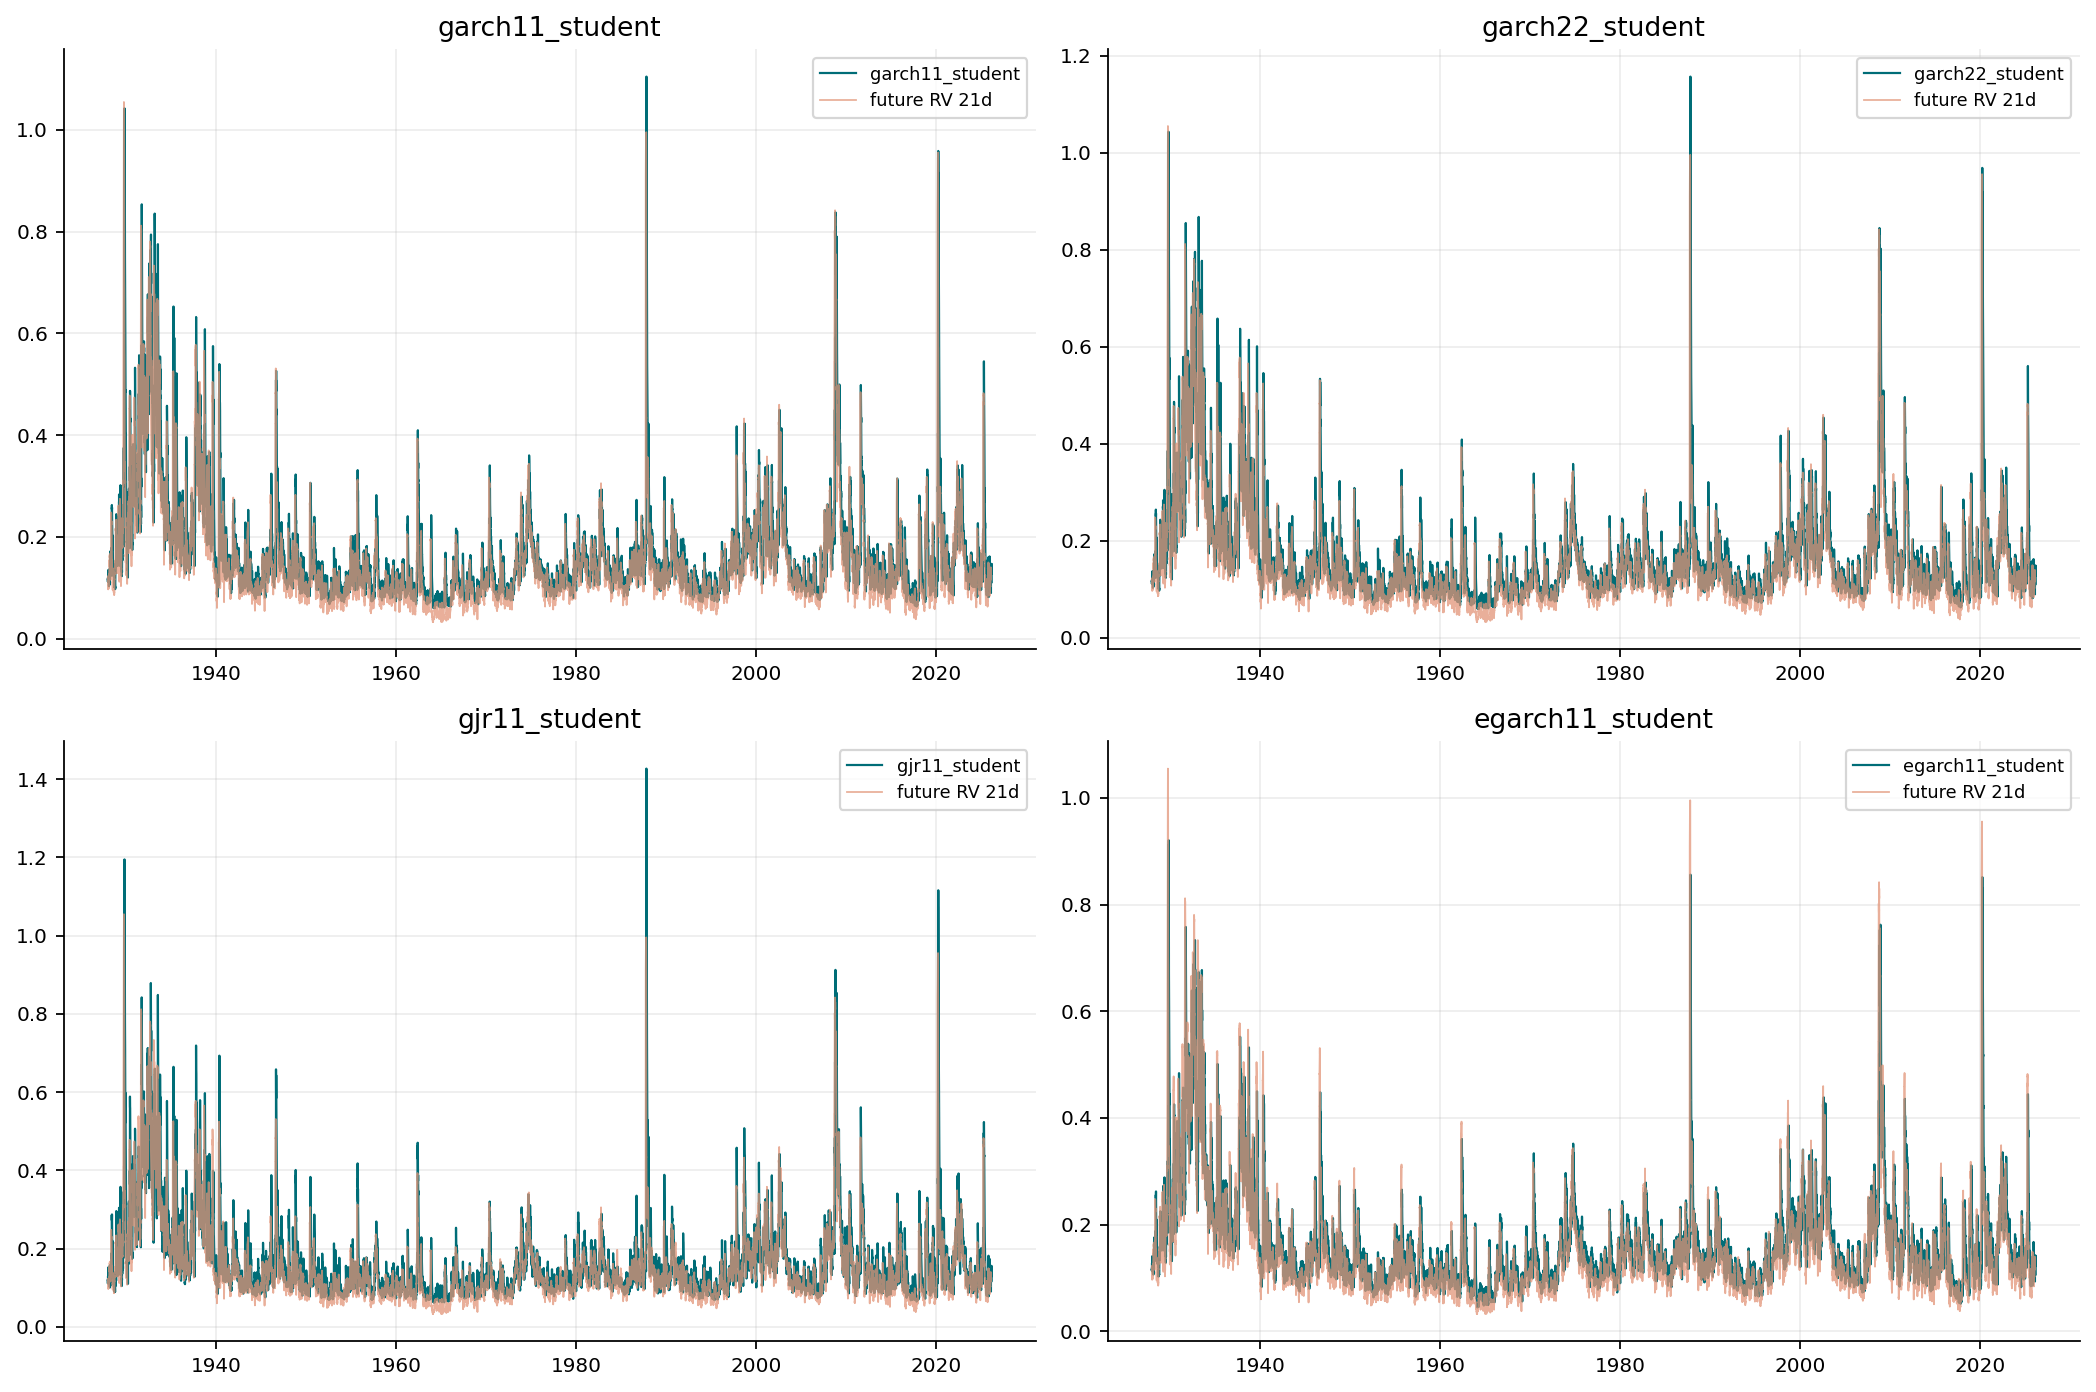

,model,lb_resid_p_10,lb_resid_p_20,lb_sq_p_10,lb_sq_p_20,arch_lm_stat_10,arch_lm_p_10,persistence_like_sum,half_life_days_garch11_style
0,garch22_normal,0.000000,0.000000,0.016558,0.017778,21.475984,0.018008,0.994386,1.976055
1,gjr11_student,0.000000,0.000000,0.006687,0.015659,24.185792,0.007122,1.050137,10.597207
2,gjr11_normal,0.000000,0.000000,0.007758,0.015556,23.691409,0.008463,1.041390,11.844375
3,garch11_normal,0.000000,0.000000,0.000225,0.000338,32.890961,0.000284,0.995127,141.886151
4,garch22_student,0.000000,0.000000,0.000069,0.000167,35.765975,0.000092,0.995482,4.438745
5,garch11_student,0.000000,0.000000,0.000002,0.000006,44.483407,0.000003,0.995904,168.891522
6,egarch11_normal,0.000000,0.000000,0.000000,0.000000,71.828295,0.000000,1.188274,NaN
7,egarch11_student,0.000000,0.000000,0.000000,0.000000,113.512408,0.000000,1.162521,NaN


In [7]:
def fit_arch_model_visible(returns_pct, vol, p, q, dist, o=0, maxiter=600):
    model = arch_model( returns_pct, mean="Zero", 
                       vol=vol, p=p, o=o, q=q, dist=dist, rescale=False)
    
    res = model.fit(disp="off", show_warning=False, options={"maxiter": int(maxiter)})
    return model, res

model_specs = [
    {"name": "garch11_normal", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "garch11_student", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
    {"name": "garch22_normal", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "normal"},
    {"name": "garch22_student", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "t"},
    {"name": "gjr11_normal", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "normal"},
    {"name": "gjr11_student", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"},
    {"name": "egarch11_normal", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "egarch11_student", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "t"}]

full_sample_fits = {}
fit_rows = []
for spec in model_specs:
    model, res = fit_arch_model_visible( returns_pct=ret_pct,
                                             vol=spec["vol"], p=spec["p"],
                                             o=spec["o"], q=spec["q"],
                                             dist=spec["dist"])
        
    full_sample_fits[spec["name"]] = {"model": model, "res": res, "spec": spec}
    params = res.params.to_dict()
    fit_rows.append({
        "model": spec["name"],
        "loglik": float(res.loglikelihood),
        "aic": float(res.aic),
        "bic": float(res.bic),
        "omega": float(params.get("omega", np.nan)),
        "alpha1": float(params.get("alpha[1]", np.nan)),
        "alpha2": float(params.get("alpha[2]", np.nan)),
        "gamma1": float(params.get("gamma[1]", np.nan)),
        "beta1": float(params.get("beta[1]", np.nan)),
        "beta2": float(params.get("beta[2]", np.nan)),
        "nu": float(params.get("nu", np.nan))})


df_full_sample_fit = pd.DataFrame(fit_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
display(df_full_sample_fit)

selected_models_for_plot = [m for m in ["garch11_student", "garch22_student", "gjr11_student", "egarch11_student"] if m in full_sample_fits]
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), sharex=False)
axes = axes.ravel()
for ax, name in zip(axes, selected_models_for_plot):
    res = full_sample_fits[name]["res"]
    cond_vol = np.asarray(res.conditional_volatility, dtype=float) / 100.0 * np.sqrt(annualization)
    ax.plot(returns_series["trade_date"], cond_vol, lw=1.0, label=name)
    ax.plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.8, alpha=0.75, label="future RV 21d")
    ax.set_title(name)
    ax.legend(loc="best")
for ax in axes[len(selected_models_for_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

diag_rows = []
for name, entry in full_sample_fits.items():
    res = entry["res"]
    std_resid = pd.Series(res.std_resid).replace([np.inf, -np.inf], np.nan).dropna()
    if len(std_resid) < 40:
        continue
    lb_r = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
    lb_s = acorr_ljungbox(std_resid ** 2, lags=[10, 20], return_df=True)
    arch_lm = het_arch(std_resid, nlags=10)
    params = res.params
    persistence = float(np.nansum([params.get(k, np.nan) for k in params.index if (k.startswith("alpha[") or k.startswith("beta[") or k.startswith("gamma["))]))
    alpha1 = float(params.get("alpha[1]", np.nan))
    beta1 = float(params.get("beta[1]", np.nan))
    half_life = math.log(0.5) / math.log(alpha1 + beta1) if np.isfinite(alpha1 + beta1) and 0 < alpha1 + beta1 < 1 else np.nan
    diag_rows.append({
        "model": name,
        "lb_resid_p_10": float(lb_r["lb_pvalue"].iloc[0]),
        "lb_resid_p_20": float(lb_r["lb_pvalue"].iloc[-1]),
        "lb_sq_p_10": float(lb_s["lb_pvalue"].iloc[0]),
        "lb_sq_p_20": float(lb_s["lb_pvalue"].iloc[-1]),
        "arch_lm_stat_10": float(arch_lm[0]),
        "arch_lm_p_10": float(arch_lm[1]),
        "persistence_like_sum": persistence,
        "half_life_days_garch11_style": half_life,
    })
df_ts_diagnostics = pd.DataFrame(diag_rows).sort_values("lb_sq_p_20", ascending=False).reset_index(drop=True)
display(df_ts_diagnostics)


In [8]:
def make_har_features_visible(rv_daily, weekly_window=5, monthly_window=22, use_log=True, eps=eps):
    rv = pd.Series(rv_daily).copy()
    rv.index = pd.to_datetime(rv.index, errors="coerce")
    rv = pd.to_numeric(rv, errors="coerce").replace([np.inf, -np.inf], np.nan).sort_index()
    features = pd.DataFrame(index=rv.index)
    features["rv_daily"] = rv
    features["rv_weekly"] = rv.rolling(weekly_window, min_periods=weekly_window).mean()
    features["rv_monthly"] = rv.rolling(monthly_window, min_periods=monthly_window).mean()
    if use_log:
        features = np.log(features.clip(lower=eps))
        features = features.rename(columns=lambda c: "log_" + c)
    return features

def forward_realized_var_sum(returns, horizon):
    r = pd.Series(returns).copy()
    vals = pd.to_numeric(r, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(vals), np.nan, dtype=float)
    h = int(horizon)
    for i in range(len(vals) - h):
        window = vals[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            out[i] = float(np.sum(window * window))
    return pd.Series(out, index=r.index, name=f"realized_var_sum_{h}")

def fit_har_ols_visible(features, target_sum, use_log=True, eps=eps):
    data = features.join(target_sum.rename("target"), how="inner").replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < features.shape[1] + 20:
        raise ValueError("not enough HAR-RV observations")
    y = pd.to_numeric(data["target"], errors="coerce")
    if use_log:
        y = np.log(y.clip(lower=eps))
    X = np.column_stack([np.ones(len(data)), data[features.columns].to_numpy(dtype=float)])
    beta, *_ = np.linalg.lstsq(X, np.asarray(y, dtype=float), rcond=None)
    return pd.Series(beta, index=["const", *features.columns])

def predict_har_sum_visible(params, feature_row, use_log=True, eps=eps):
    x = np.r_[1.0, feature_row.to_numpy(dtype=float)]
    pred = float(np.dot(params.to_numpy(dtype=float), x))
    if use_log:
        pred = float(np.exp(pred))
    return max(pred, eps)

def rolling_har_forecasts_visible(returns_df, signal_dates, horizons=horizons, train_window=756, annualization=annualization, use_log=True, eps=eps):
    ser = returns_df.set_index("trade_date")["spx_ret"].dropna().sort_index()
    rv_daily = ser * ser
    features = make_har_features_visible(rv_daily, use_log=use_log, eps=eps)
    targets = {int(h): forward_realized_var_sum(ser, int(h)) for h in horizons}
    dates = pd.DatetimeIndex(ser.index)
    date_to_pos = {pd.Timestamp(d).normalize(): i for i, d in enumerate(dates)}
    records = []
    for signal_date in pd.DatetimeIndex(pd.to_datetime(signal_dates)).normalize().unique().sort_values():
        pos = date_to_pos.get(pd.Timestamp(signal_date).normalize())
        if pos is None or pos < train_window or pos + max(horizons) >= len(ser):
            continue
        if signal_date not in features.index or features.loc[[signal_date]].isna().any(axis=None):
            continue
        for h in horizons:
            h = int(h)
            known_end_pos = pos - h
            if known_end_pos <= 0:
                continue
            train_start = max(0, known_end_pos - int(train_window) + 1)
            train_dates = dates[train_start : known_end_pos + 1]
            try:
                params = fit_har_ols_visible(features.loc[train_dates], targets[h].loc[train_dates], use_log=use_log, eps=eps)
                forecast_sum = predict_har_sum_visible(params, features.loc[signal_date], use_log=use_log, eps=eps)
            except Exception:
                continue
            realized_sum = float(targets[h].loc[signal_date])
            forecast_ann = annualization / h * forecast_sum
            realized_ann = annualization / h * realized_sum if np.isfinite(realized_sum) else np.nan
            records.append({
                "date": signal_date,
                "model": "har_rv",
                "horizon": h,
                "forecast_var_sum": forecast_sum,
                "forecast_var_ann": forecast_ann,
                "forecast_vol_ann": float(np.sqrt(max(forecast_ann, 0.0))),
                "realized_var_sum": realized_sum,
                "realized_var_ann": realized_ann,
                "realized_vol_ann": float(np.sqrt(max(realized_ann, 0.0))) if np.isfinite(realized_ann) else np.nan,
                "n_train": int(len(train_dates))})
    return pd.DataFrame(records).sort_values(["date", "horizon"]).reset_index(drop=True)

har_feature_preview = make_har_features_visible(df_market.set_index("trade_date")["spx_ret"].dropna() ** 2).dropna().head()


In [9]:
train_window = 756
FAST_DEMO_MODE = False
signal_dates_all = pd.DatetimeIndex(iv_30d_daily["date"].dropna().unique()).sort_values()
if FAST_DEMO_MODE:
    signal_dates = signal_dates_all[::5]
else:
    signal_dates = signal_dates_all
signal_dates = signal_dates[(signal_dates >= returns_series["trade_date"].min()) & (signal_dates <= returns_series["trade_date"].max())]
display(pd.DataFrame({"metric": ["signal_dates", "first_signal", "last_signal"], "value": [len(signal_dates), signal_dates.min(), signal_dates.max()]}))

def arch_forecast_variance_vector(res, max_horizon, simulations=500, seed=7):
    try:
        fc = res.forecast(horizon=int(max_horizon), reindex=False, method="analytic")
    except Exception:
        np.random.seed(seed)
        fc = res.forecast(horizon=int(max_horizon), reindex=False, method="simulation", simulations=int(simulations))
    return np.asarray(fc.variance.values[-1], dtype=float).reshape(-1)

def rolling_arch_forecasts_daily_refit(returns_df, signal_dates, specs, horizons=horizons, train_window=756, annualization=annualization, maxiter=500):
    data = returns_df.dropna(subset=["trade_date", "spx_ret"]).copy()
    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce").dt.normalize()
    data = data.sort_values("trade_date").reset_index(drop=True)
    dates = pd.DatetimeIndex(data["trade_date"])
    returns = data["spx_ret"].to_numpy(dtype=float)
    ret_pct_all = 100.0 * returns
    date_to_pos = {pd.Timestamp(d).normalize(): i for i, d in enumerate(dates)}
    max_h = int(max(horizons))
    records = []
    error_rows = []
    for signal_idx, signal_date in enumerate(pd.DatetimeIndex(signal_dates).normalize().unique().sort_values()):
        pos = date_to_pos.get(pd.Timestamp(signal_date).normalize())
        if pos is None or pos < train_window or pos + max_h >= len(data):
            continue
        train = ret_pct_all[pos - train_window + 1 : pos + 1]
        if not np.isfinite(train).all():
            train = train[np.isfinite(train)]
        if len(train) < train_window:
            continue
        for spec_idx, spec in enumerate(specs):
            name = spec["name"]
            try:
                _, res = fit_arch_model_visible(
                    train,
                    vol=spec["vol"],
                    p=spec["p"],
                    o=spec.get("o", 0),
                    q=spec["q"],
                    dist=spec["dist"],
                    maxiter=maxiter,
                )
                fc_pct2 = arch_forecast_variance_vector(res, max_h, seed=seed + 1009 * spec_idx + signal_idx)
            except Exception as exc:
                error_rows.append({"date": signal_date, "model": name, "error": str(exc)})
                continue
            for h in horizons:
                h = int(h)
                forecast_sum = float(np.sum(fc_pct2[:h]) / (100.0 ** 2))
                realized_window = returns[pos + 1 : pos + 1 + h]
                realized_sum = float(np.sum(realized_window * realized_window)) if len(realized_window) == h and np.isfinite(realized_window).all() else np.nan
                forecast_ann = annualization / h * forecast_sum
                realized_ann = annualization / h * realized_sum if np.isfinite(realized_sum) else np.nan
                records.append({
                    "date": signal_date,
                    "model": name,
                    "horizon": h,
                    "forecast_var_sum": forecast_sum,
                    "forecast_var_ann": forecast_ann,
                    "forecast_vol_ann": float(np.sqrt(max(forecast_ann, 0.0))),
                    "realized_var_sum": realized_sum,
                    "realized_var_ann": realized_ann,
                    "realized_vol_ann": float(np.sqrt(max(realized_ann, 0.0))) if np.isfinite(realized_ann) else np.nan,
                    "n_train": int(len(train)),
                })
    out = pd.DataFrame(records).sort_values(["date", "model", "horizon"]).reset_index(drop=True)
    errors = pd.DataFrame(error_rows)
    return out, errors

t0 = time.time()
df_garch_fc, df_arch_errors = rolling_arch_forecasts_daily_refit(
    returns_series,
    signal_dates,
    model_specs,
    horizons=horizons,
    train_window=train_window,
    maxiter=500)

df_har_fc = rolling_har_forecasts_visible(
    returns_series,
    signal_dates,
    horizons=horizons,
    train_window=train_window)

df_fc_signal = pd.concat([df_garch_fc, df_har_fc], ignore_index=True).sort_values(["date", "model", "horizon"]).reset_index(drop=True)
print(f"Forecast generation time: {time.time() - t0:,.1f}s")
print("Forecast panel rows:", len(df_fc_signal), "models:", sorted(df_fc_signal["model"].dropna().unique()))
if not df_arch_errors.empty:
    display(df_arch_errors.groupby("model").size().rename("fit_errors").reset_index())
display(df_fc_signal.head())


,metric,value
0,signal_dates,505
1,first_signal,2022-01-03 00:00:00
2,last_signal,2023-12-29 00:00:00


Forecast generation time: 180.6s
Forecast panel rows: 26784 models: ['egarch11_normal', 'egarch11_student', 'garch11_normal', 'garch11_student', 'garch22_normal', 'garch22_student', 'gjr11_normal', 'gjr11_student', 'har_rv']


,date,model,horizon,forecast_var_sum,forecast_var_ann,forecast_vol_ann,realized_var_sum,realized_var_ann,realized_vol_ann,n_train
0,2022-01-03,egarch11_normal,1,0.000066,0.016597,0.128828,0.000000,0.000100,0.009998,756
1,2022-01-03,egarch11_normal,5,0.000382,0.019250,0.138745,0.000403,0.020330,0.142585,756
2,2022-01-03,egarch11_normal,10,0.000904,0.022783,0.150941,0.001045,0.026343,0.162306,756
3,2022-01-03,egarch11_normal,21,0.002304,0.027653,0.166292,0.002881,0.034566,0.185920,756
4,2022-01-03,egarch11_normal,42,0.005372,0.032233,0.179536,0.007120,0.042720,0.206689,756


,model,rank_mean
0,egarch11_normal,1.833333
1,har_rv,3.466667
2,egarch11_student,4.100000
3,garch11_normal,4.566667
4,garch22_normal,4.733333
5,gjr11_normal,4.933333
6,garch11_student,6.666667
7,garch22_student,7.300000
8,gjr11_student,7.400000


,model,horizon,qlike_var,rmse_var,mae_var,rmse_vol,mae_vol,corr_var,corr_vol,mz_alpha,mz_beta,mz_r2,mz_beta_p,n_obs
0,gjr11_normal,21,-4.932524,0.002474,0.001430,0.054454,0.038578,0.628361,0.745058,0.015491,0.473870,0.394838,0.000000,496
1,gjr11_student,21,-4.920153,0.003027,0.001703,0.061875,0.043752,0.633865,0.745988,0.017447,0.393508,0.401785,0.000000,496
2,egarch11_normal,21,-4.916631,0.001762,0.001285,0.048780,0.038888,0.666022,0.739956,0.002896,0.819093,0.443586,0.000000,496
3,egarch11_student,21,-4.913315,0.001884,0.001347,0.050846,0.040036,0.655391,0.733183,0.006185,0.713029,0.429537,0.000000,496
4,garch11_normal,21,-4.910721,0.002100,0.001382,0.052841,0.040067,0.597082,0.695835,0.012888,0.579291,0.356507,0.000000,496
5,garch11_student,21,-4.907991,0.002312,0.001482,0.056094,0.041847,0.602120,0.701183,0.014182,0.513262,0.362549,0.000000,496
6,garch22_normal,21,-4.907898,0.002064,0.001380,0.052565,0.040271,0.581245,0.682570,0.012891,0.596595,0.337846,0.000000,496
7,garch22_student,21,-4.904146,0.002333,0.001507,0.056656,0.042634,0.588334,0.690086,0.014523,0.506146,0.346136,0.000000,496
8,har_rv,21,-4.880936,0.001882,0.001286,0.051154,0.038934,0.610135,0.679743,-0.000131,1.209987,0.372264,0.000000,496


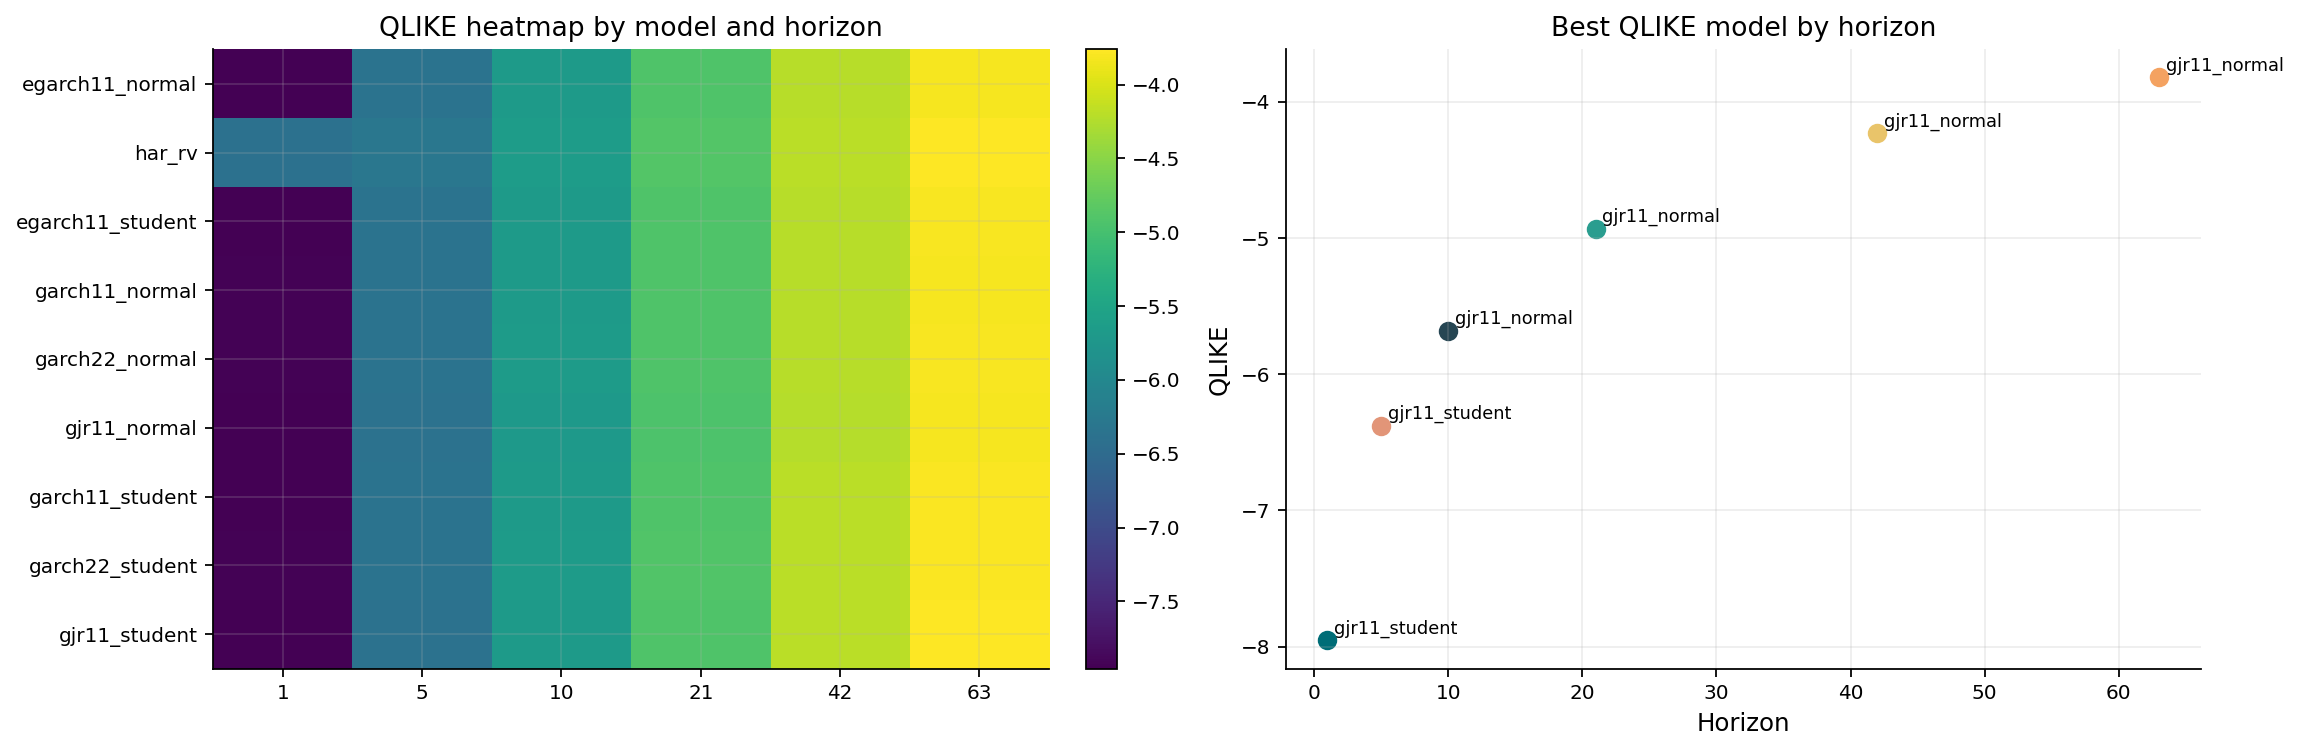

In [10]:
def qlike_loss(realized_var, forecast_var, eps=eps):
    realized_var = np.asarray(realized_var, dtype=float)
    forecast_var = np.asarray(forecast_var, dtype=float)
    mask = np.isfinite(realized_var) & np.isfinite(forecast_var) & (realized_var > 0) & (forecast_var > 0)
    if mask.sum() == 0:
        return np.nan
    rv = np.clip(realized_var[mask], eps, None)
    fv = np.clip(forecast_var[mask], eps, None)
    return float(np.mean(np.log(fv) + rv / fv))

def qlike_array(realized_var, forecast_var, eps=eps):
    rv = np.asarray(realized_var, dtype=float)
    fv = np.asarray(forecast_var, dtype=float)
    out = np.full(len(rv), np.nan, dtype=float)
    mask = np.isfinite(rv) & np.isfinite(fv) & (rv > 0) & (fv > 0)
    out[mask] = np.log(np.clip(fv[mask], eps, None)) + np.clip(rv[mask], eps, None) / np.clip(fv[mask], eps, None)
    return out

def mz_regression(y, x, maxlags=5):
    z = pd.DataFrame({"y": y, "x": x}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(z) < 25:
        return {"alpha": np.nan, "beta": np.nan, "r2": np.nan, "alpha_p": np.nan, "beta_p": np.nan, "n_obs": int(len(z))}
    X = sm.add_constant(z["x"])
    res = sm.OLS(z["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return {
        "alpha": float(res.params.get("const", np.nan)),
        "beta": float(res.params.get("x", np.nan)),
        "r2": float(res.rsquared),
        "alpha_p": float(res.pvalues.get("const", np.nan)),
        "beta_p": float(res.pvalues.get("x", np.nan)),
        "n_obs": int(len(z))}

def dm_test(loss_a, loss_b, h=1):
    d = pd.Series(np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    n = len(d)
    if n < max(20, int(h) + 5):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    mean_d = float(np.mean(d))
    long_run = float(np.var(d, ddof=1))
    max_lag = int(max(1, h - 1))
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        long_run += 2.0 * (1.0 - lag / (max_lag + 1.0)) * cov
    if long_run <= 0 or not np.isfinite(long_run):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    stat = mean_d / math.sqrt(long_run / n)
    pval = 2.0 * (1.0 - norm.cdf(abs(stat)))
    return {"dm_stat": float(stat), "dm_pvalue": float(pval), "n": int(n)}

score_rows = []
for (model, h), g in df_fc_signal.dropna(subset=["realized_var_sum", "forecast_var_sum"]).groupby(["model", "horizon"]):
    err_var = g["forecast_var_sum"] - g["realized_var_sum"]
    err_vol = g["forecast_vol_ann"] - g["realized_vol_ann"]
    corr_var = g[["forecast_var_ann", "realized_var_ann"]].corr().iloc[0, 1] if len(g) >= 3 else np.nan
    corr_vol = g[["forecast_vol_ann", "realized_vol_ann"]].corr().iloc[0, 1] if len(g) >= 3 else np.nan
    mz = mz_regression(g["realized_var_ann"], g["forecast_var_ann"], maxlags=int(h))
    score_rows.append({
        "model": model,
        "horizon": int(h),
        "qlike_var": qlike_loss(g["realized_var_sum"], g["forecast_var_sum"]),
        "rmse_var": float(np.sqrt(np.nanmean(err_var * err_var))),
        "mae_var": float(np.nanmean(np.abs(err_var))),
        "rmse_vol": float(np.sqrt(np.nanmean(err_vol * err_vol))),
        "mae_vol": float(np.nanmean(np.abs(err_vol))),
        "corr_var": float(corr_var) if np.isfinite(corr_var) else np.nan,
        "corr_vol": float(corr_vol) if np.isfinite(corr_vol) else np.nan,
        "mz_alpha": mz["alpha"],
        "mz_beta": mz["beta"],
        "mz_r2": mz["r2"],
        "mz_beta_p": mz["beta_p"],
        "n_obs": int(len(g))})

df_scores = pd.DataFrame(score_rows).sort_values(["horizon", "qlike_var", "rmse_vol"]).reset_index(drop=True)
ranked = df_scores.copy()
for metric in ["qlike_var", "rmse_var", "mae_var", "rmse_vol", "mae_vol"]:
    ranked[f"rank_{metric}"] = ranked.groupby("horizon")[metric].rank(method="average", ascending=True)
ranked["rank_mean"] = ranked[[c for c in ranked.columns if c.startswith("rank_")]].mean(axis=1)
df_model_ranks = ranked.groupby("model", as_index=False)["rank_mean"].mean().sort_values("rank_mean").reset_index(drop=True)

display(df_model_ranks)
display(df_scores[df_scores["horizon"] == 21].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))

dm_rows = []
for h in horizons:
    h_scores = df_scores[df_scores["horizon"] == h].sort_values("qlike_var")
    if h_scores.empty:
        continue
    benchmark = str(h_scores.iloc[0]["model"])
    g = df_fc_signal[df_fc_signal["horizon"] == h].dropna(subset=["realized_var_sum", "forecast_var_sum"]).copy()
    base = g[g["model"] == benchmark].sort_values("date")
    for competitor in sorted(set(g["model"]) - {benchmark}):
        other = g[g["model"] == competitor].sort_values("date")
        joined = base[["date", "forecast_var_sum", "realized_var_sum"]].merge(
            other[["date", "forecast_var_sum"]],
            on="date",
            how="inner",
            suffixes=("_benchmark", "_other"),
        )
        if joined.empty:
            continue
        loss_b = qlike_array(joined["realized_var_sum"], joined["forecast_var_sum_benchmark"])
        loss_o = qlike_array(joined["realized_var_sum"], joined["forecast_var_sum_other"])
        dm_rows.append({"horizon": int(h), "benchmark_model": benchmark, "competitor": competitor, **dm_test(loss_b, loss_o, h=int(h))})
df_dm = pd.DataFrame(dm_rows).sort_values(["horizon", "dm_pvalue"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
rank_pivot = df_scores.pivot(index="model", columns="horizon", values="qlike_var").loc[df_model_ranks["model"]]
im = axes[0].imshow(rank_pivot.to_numpy(dtype=float), aspect="auto")
axes[0].set_xticks(range(len(rank_pivot.columns)), rank_pivot.columns)
axes[0].set_yticks(range(len(rank_pivot.index)), rank_pivot.index)
axes[0].set_title("QLIKE heatmap by model and horizon")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
for h in horizons:
    tmp = df_scores[df_scores["horizon"] == h].sort_values("qlike_var").head(1)
    if not tmp.empty:
        axes[1].scatter([h], [tmp.iloc[0]["qlike_var"]], s=60)
        axes[1].annotate(tmp.iloc[0]["model"], (h, tmp.iloc[0]["qlike_var"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
axes[1].set_title("Best QLIKE model by horizon")
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("QLIKE")
plt.tight_layout()
plt.show()


horizon,1,5,10,21,42,63
selected_model,,,,,,
egarch11_normal,76.000000,166.000000,192.000000,195.000000,195.000000,168.000000
egarch11_student,110.000000,34.000000,8.000000,8.000000,0.000000,0.000000
garch11_student,16.000000,2.000000,0.000000,0.000000,0.000000,21.000000
garch22_student,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000
gjr11_normal,6.000000,69.000000,53.000000,54.000000,51.000000,110.000000
gjr11_student,212.000000,180.000000,54.000000,5.000000,0.000000,0.000000
har_rv,0.000000,0.000000,139.000000,173.000000,168.000000,95.000000
median_ensemble,41.000000,45.000000,50.000000,61.000000,82.000000,102.000000


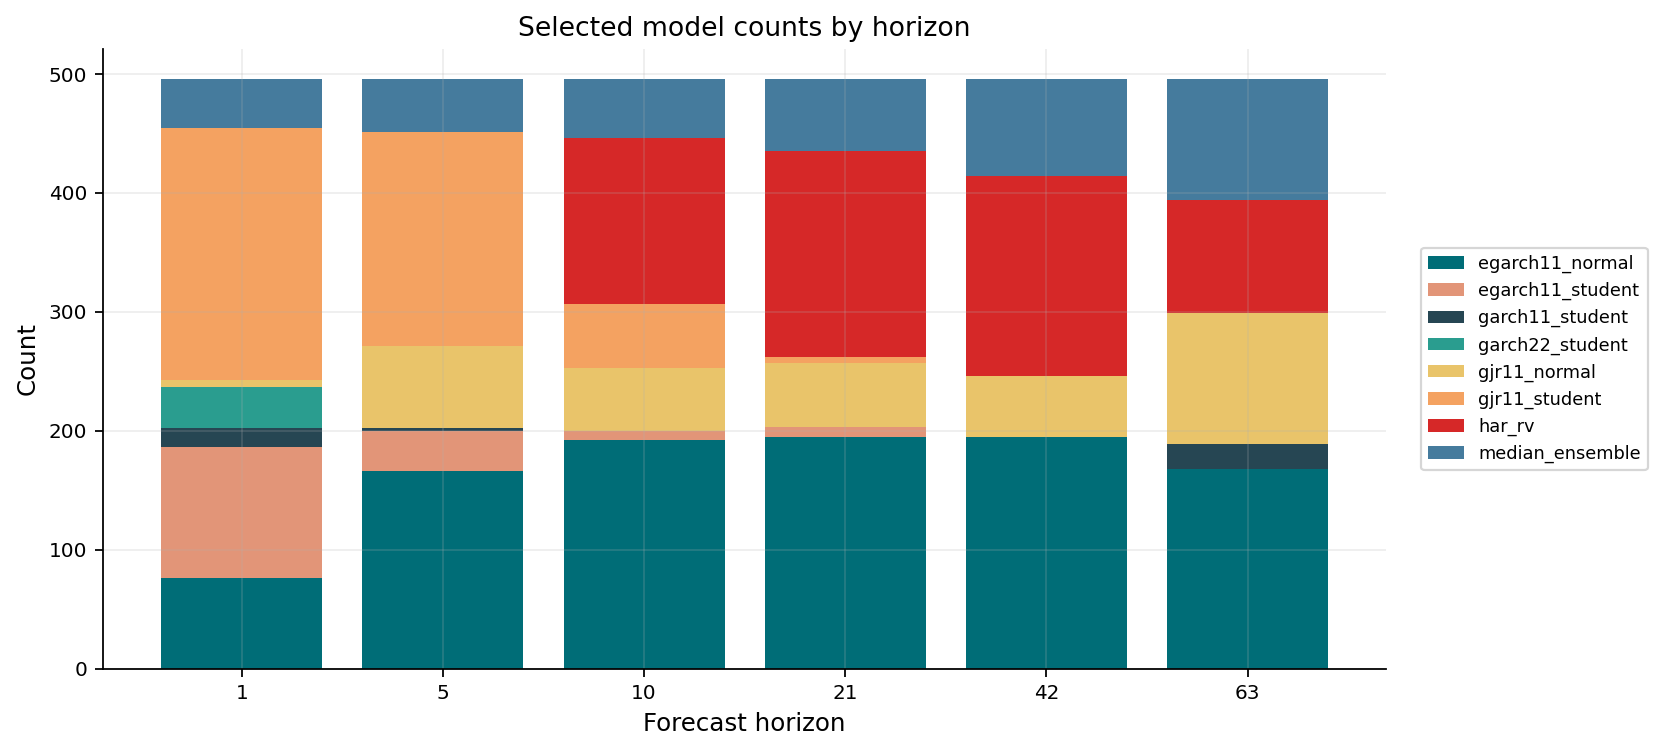

In [11]:
def add_realized_availability_dates(forecast_panel, market_dates):
    dates = pd.DatetimeIndex(pd.to_datetime(market_dates)).normalize()
    date_to_pos = {pd.Timestamp(d): i for i, d in enumerate(dates)}
    out = forecast_panel.copy()
    available = []
    for _, row in out.iterrows():
        d = pd.Timestamp(row["date"]).normalize()
        h = int(row["horizon"])
        pos = date_to_pos.get(d)
        if pos is None or pos + h >= len(dates):
            available.append(pd.NaT)
        else:
            available.append(pd.Timestamp(dates[pos + h]).normalize())
    out["realized_available_date"] = available
    return out

def select_model_by_rolling_past_loss(df_fc_signal, horizons=horizons,
                                      lookback=126, min_obs=40,
                                      fallback="median_ensemble", eps=eps):

    data = df_fc_signal.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce").dt.normalize()
    data["horizon"] = data["horizon"].astype(int)
    data = add_realized_availability_dates(data, df_market["trade_date"])
    data["loss_value"] = qlike_array(data["realized_var_sum"], data["forecast_var_sum"], eps=eps)
    rows = []
    for (date, horizon), current in data.groupby(["date", "horizon"], sort=True):
        if int(horizon) not in horizons:
            continue
        current = current.dropna(subset=["forecast_var_sum"]).copy()
        if current.empty:
            continue
        past = data[
            (data["horizon"] == int(horizon))
            & (data["realized_available_date"].notna())
            & (data["realized_available_date"] < pd.Timestamp(date))
            & (data["loss_value"].notna())].copy()
        if lookback and lookback > 0:
            keep_dates = pd.Index(sorted(past["date"].unique()))[-int(lookback):]
            past = past[past["date"].isin(keep_dates)]
        recent = (
            past.groupby("model")
            .agg(recent_loss=("loss_value", "mean"), n_loss=("loss_value", "count"))
            .query("n_loss >= @min_obs")
            .sort_values(["recent_loss", "n_loss"], ascending=[True, False]))
        current_by_model = current.set_index("model", drop=False)
        selected_model = None
        selection_reason = "rolling_past_qlike"
        recent_loss = np.nan
        n_loss = 0
        if not recent.empty:
            valid_ranked = [m for m in recent.index if m in current_by_model.index]
            if valid_ranked:
                selected_model = str(valid_ranked[0])
                selected = current_by_model.loc[selected_model]
                if isinstance(selected, pd.DataFrame):
                    selected = selected.iloc[0]
                recent_loss = float(recent.loc[selected_model, "recent_loss"])
                n_loss = int(recent.loc[selected_model, "n_loss"])
        if selected_model is None:
            selected_model = fallback
            selection_reason = "fallback_median_ensemble"
            selected = current.iloc[0].copy()
            selected["forecast_var_sum"] = float(current["forecast_var_sum"].median())
            selected["forecast_var_ann"] = annualization / int(horizon) * float(selected["forecast_var_sum"])
            selected["forecast_vol_ann"] = float(np.sqrt(max(selected["forecast_var_ann"], 0.0)))
        rows.append({
            "date": pd.Timestamp(date),
            "horizon": int(horizon),
            "selected_model": selected_model,
            "selection_reason": selection_reason,
            "forecast_var_sum": float(selected["forecast_var_sum"]),
            "forecast_var_ann": float(selected["forecast_var_ann"]),
            "forecast_vol_ann": float(selected["forecast_vol_ann"]),
            "realized_var_sum": float(selected["realized_var_sum"]) if pd.notna(selected["realized_var_sum"]) else np.nan,
            "realized_var_ann": float(selected["realized_var_ann"]) if pd.notna(selected["realized_var_ann"]) else np.nan,
            "realized_vol_ann": float(selected["realized_vol_ann"]) if pd.notna(selected["realized_vol_ann"]) else np.nan,
            "recent_loss": recent_loss,
            "n_loss": n_loss,
        })
    return pd.DataFrame(rows).sort_values(["date", "horizon"]).reset_index(drop=True)

selected_fc = select_model_by_rolling_past_loss(df_fc_signal,
    horizons=horizons, lookback=126, min_obs=40,
    fallback="median_ensemble")

selected_model_counts = selected_fc.groupby(["horizon", "selected_model"]).size().rename("n").reset_index()
display(selected_model_counts.pivot_table(index="selected_model", columns="horizon", values="n", fill_value=0))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
plot_counts = selected_model_counts.pivot(index="selected_model", columns="horizon", values="n").fillna(0)
bottom = np.zeros(len(plot_counts.columns))
for model, row in plot_counts.iterrows():
    vals = row.to_numpy(dtype=float)
    ax.bar([str(h) for h in plot_counts.columns], vals, bottom=bottom, label=model)
    bottom += vals
ax.set_title("Selected model counts by horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Count")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


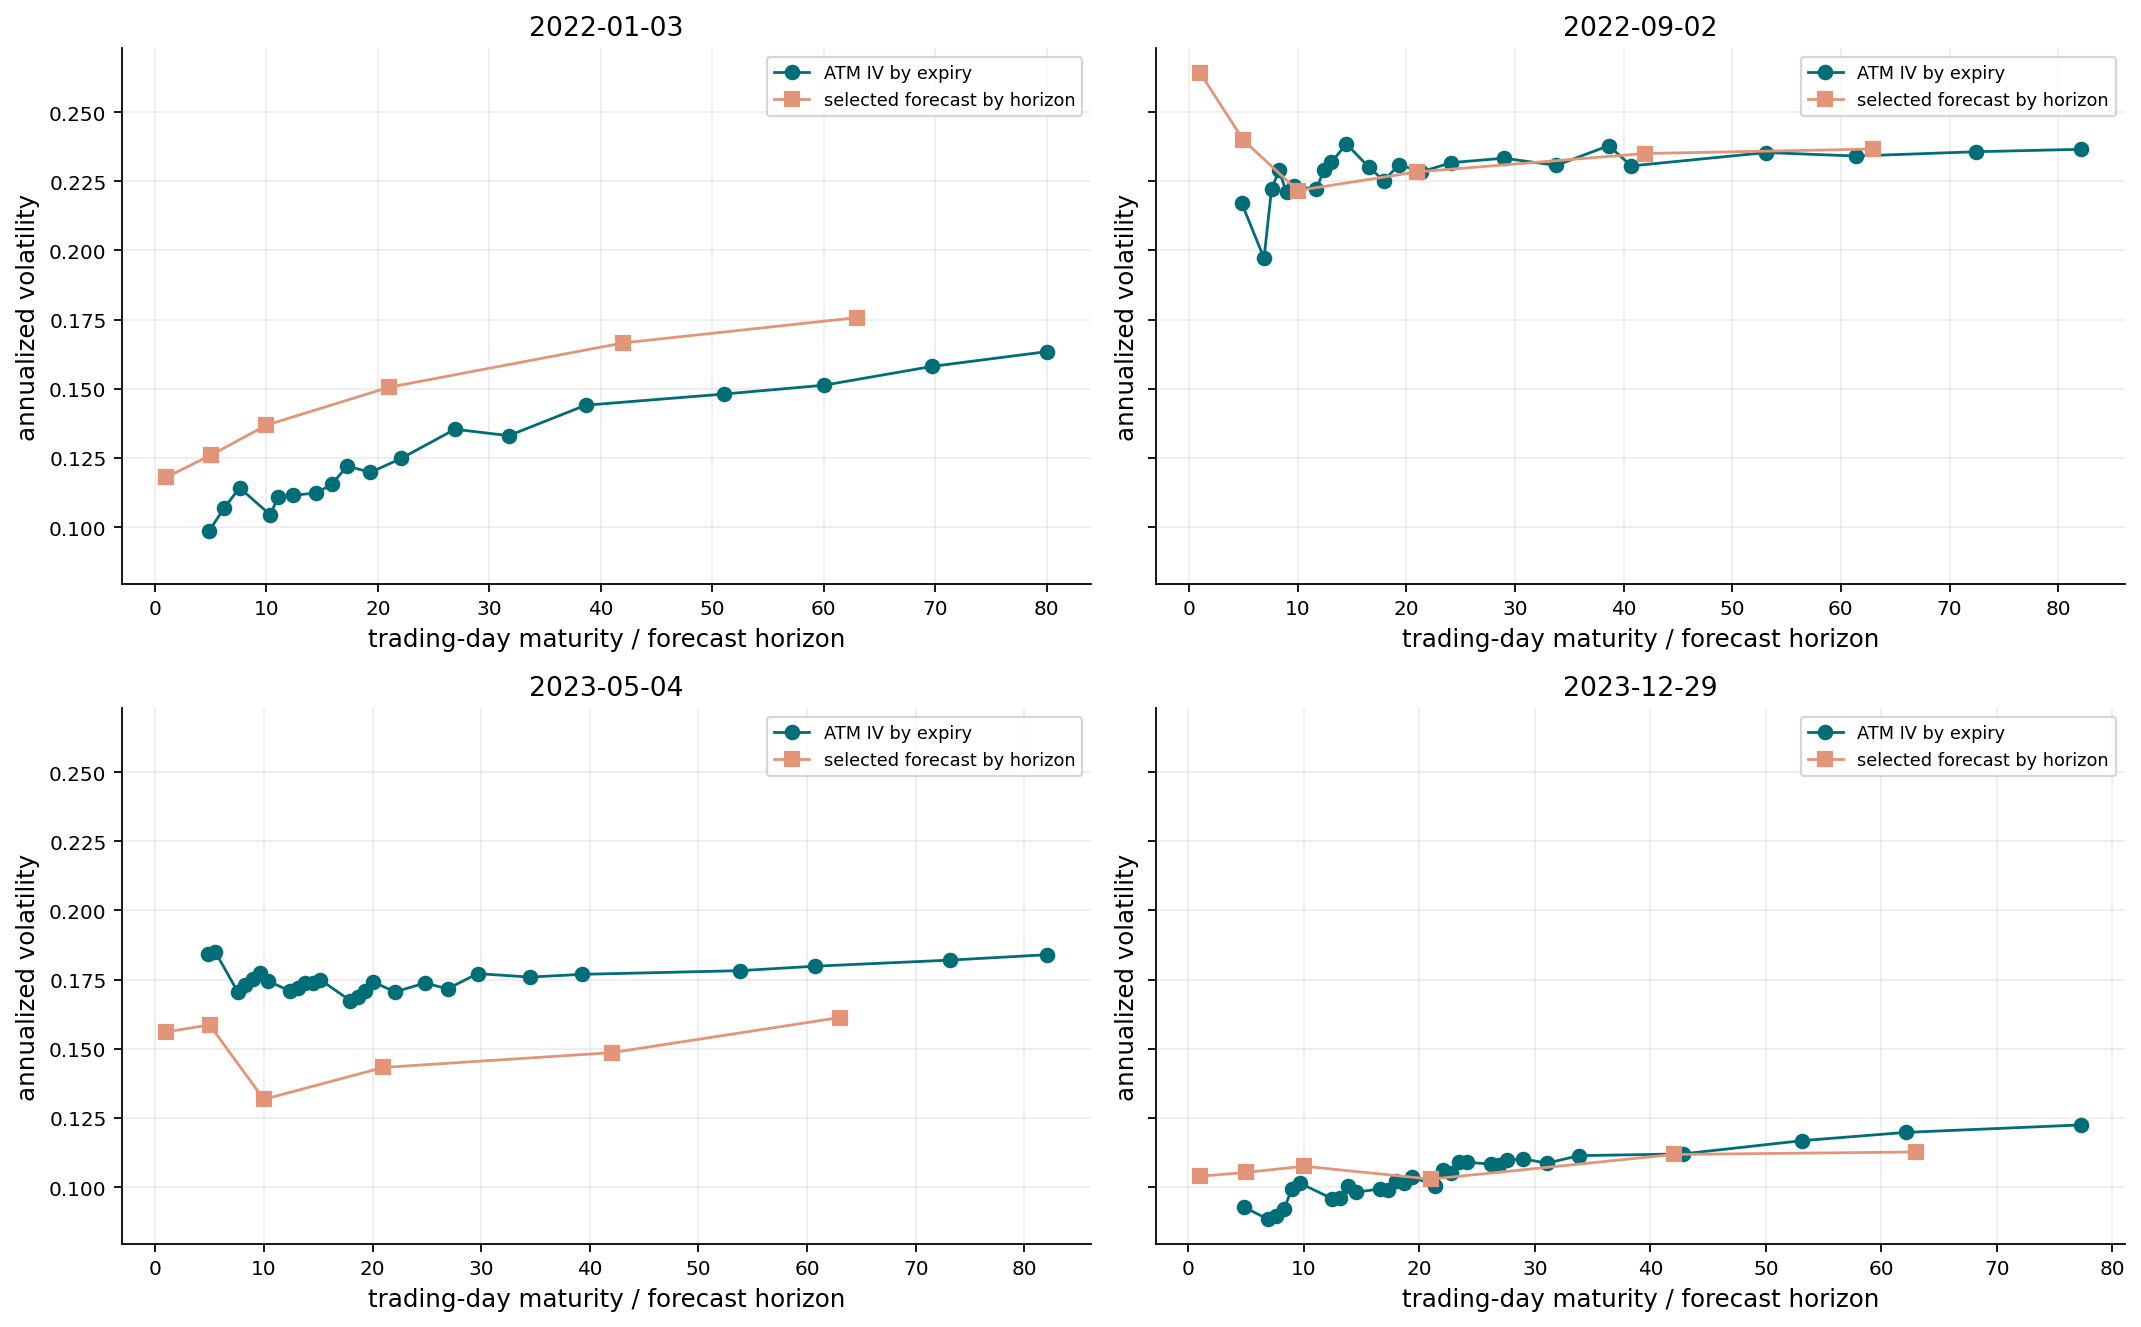

,date,horizon,selected_model,forecast_vol_ann,realized_vol_ann
0,2022-01-03,1,median_ensemble,0.118018,0.009998
1,2022-01-03,5,median_ensemble,0.125970,0.142585
2,2022-01-03,10,median_ensemble,0.136869,0.162306
3,2022-01-03,21,median_ensemble,0.150552,0.185920
4,2022-01-03,42,median_ensemble,0.166578,0.206689
5,2022-01-03,63,median_ensemble,0.175724,0.212171
990,2022-09-02,1,gjr11_student,0.264238,0.065140
991,2022-09-02,5,gjr11_normal,0.239860,0.191962
992,2022-09-02,10,egarch11_normal,0.221646,0.271466
993,2022-09-02,21,egarch11_normal,0.228383,0.278505


In [12]:
term_iv_panel = iv_panel_all.copy()
term_iv_panel = term_iv_panel[
    term_iv_panel["dte_trading"].between(min(horizons), max(horizons) * 365.25 / 252.0, inclusive="both")].copy()
term_iv_panel = term_iv_panel.replace([np.inf, -np.inf], np.nan).dropna(subset=["date", "dte_trading", "atm_iv_mid"])

forecast_term_dates = selected_fc.groupby("date")["horizon"].nunique()
iv_term_dates = term_iv_panel.groupby("date")["expiry"].nunique()
eligible_term_dates = pd.Index(sorted(set(forecast_term_dates[forecast_term_dates >= len(horizons)].index) & set(iv_term_dates[iv_term_dates >= 3].index)))
if len(eligible_term_dates) == 0:
    print("No dates have enough IV expiries and selected forecast horizons for the term-structure comparison.")
else:
    sample_positions = np.unique(np.linspace(0, len(eligible_term_dates) - 1, min(4, len(eligible_term_dates))).round().astype(int))
    term_sample_dates = [pd.Timestamp(eligible_term_dates[i]).normalize() for i in sample_positions]
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4), sharey=True)
    axes = axes.ravel()
    for ax, sample_date in zip(axes, term_sample_dates):
        iv_curve = term_iv_panel[term_iv_panel["date"].eq(sample_date)].sort_values("dte_trading")
        fc_curve = selected_fc[selected_fc["date"].eq(sample_date)].sort_values("horizon")
        ax.plot(iv_curve["dte_trading"], iv_curve["atm_iv_mid"],
                marker="o", lw=1.25, label="ATM IV by expiry")
        ax.plot(
            fc_curve["horizon"],
            fc_curve["forecast_vol_ann"],
            marker="s",
            lw=1.25,
            label="selected forecast by horizon")
        
        ax.set_title(str(sample_date.date()))
        ax.set_xlabel("trading-day maturity / forecast horizon")
        ax.set_ylabel("annualized volatility")
        ax.legend(loc="best")
    for ax in axes[len(term_sample_dates):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    display(selected_fc[selected_fc["date"].isin(term_sample_dates)][["date", "horizon", "selected_model", "forecast_vol_ann", "realized_vol_ann"]].head(24))


In [13]:
def rolling_past_percentile(series, window=63, min_periods=20):
    values = pd.Series(series, dtype=float).to_numpy()
    out = np.full(len(values), np.nan, dtype=float)
    for i in range(len(values)):
        start = max(0, i - int(window))
        hist = values[start:i]
        hist = hist[np.isfinite(hist)]
        if len(hist) >= min_periods and np.isfinite(values[i]):
            out[i] = float(np.mean(hist <= values[i]))
    return pd.Series(out, index=pd.Series(series).index)

def interpolate_selected_variance_to_dte(selected_fc, iv_daily, horizons=horizons, annualization=annualization):
    fc = selected_fc.copy()
    fc["date"] = pd.to_datetime(fc["date"], errors="coerce").dt.normalize()
    fc["horizon"] = fc["horizon"].astype(int)
    iv = iv_daily.copy()
    iv["date"] = pd.to_datetime(iv["date"], errors="coerce").dt.normalize()
    rows = []
    by_date = {d: g.sort_values("horizon") for d, g in fc.groupby("date")}
    for _, opt in iv.iterrows():
        date = pd.Timestamp(opt["date"]).normalize()
        g = by_date.get(date)
        dte_trading = float(opt["dte_trading"])
        if g is None or not np.isfinite(dte_trading) or dte_trading <= 0:
            continue
        g = g.dropna(subset=["forecast_var_sum"]).sort_values("horizon")
        if g.empty:
            continue
        x = g["horizon"].to_numpy(dtype=float)
        forecast_sum = g["forecast_var_sum"].to_numpy(dtype=float)
        realized_sum = g["realized_var_sum"].to_numpy(dtype=float)
        target = float(np.clip(dte_trading, np.nanmin(x), np.nanmax(x)))
        fc_sum_dte = float(np.interp(target, x, forecast_sum))
        rv_sum_dte = float(np.interp(target, x, realized_sum)) if np.isfinite(realized_sum).any() else np.nan
        fc_var_ann = annualization / target * fc_sum_dte
        rv_var_ann = annualization / target * rv_sum_dte if np.isfinite(rv_sum_dte) else np.nan
        nearest = g.iloc[int(np.argmin(np.abs(x - target)))]
        row = opt.to_dict()
        row.update({
            "target_horizon_trading_days": target,
            "forecast_var_sum_dte": fc_sum_dte,
            "forecast_var_ann": fc_var_ann,
            "forecast_vol_ann": float(np.sqrt(max(fc_var_ann, 0.0))),
            "future_realized_var_sum": rv_sum_dte,
            "future_realized_var_ann": rv_var_ann,
            "future_realized_vol_ann": float(np.sqrt(max(rv_var_ann, 0.0))) if np.isfinite(rv_var_ann) else np.nan,
            "selected_model": nearest["selected_model"],
            "selection_reason": nearest["selection_reason"]})
        rows.append(row)
    out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    if out.empty:
        return out
    out["atm_iv_mid"] = pd.to_numeric(out["atm_iv_mid"], errors="coerce")
    if out["atm_iv_mid"].dropna().median() > 2.0:
        out["atm_iv_mid"] = out["atm_iv_mid"] / 100.0
    out["iv_var_ann"] = out["atm_iv_mid"] ** 2
    out["vrp_var"] = out["iv_var_ann"] - out["forecast_var_ann"]
    out["vol_spread"] = out["atm_iv_mid"] - out["forecast_vol_ann"]
    z_window = 63
    min_periods = 20
    past_mean = out["vrp_var"].shift(1).rolling(z_window, min_periods=min_periods).mean()
    past_std = out["vrp_var"].shift(1).rolling(z_window, min_periods=min_periods).std(ddof=0)
    out["vrp_z"] = (out["vrp_var"] - past_mean) / past_std.replace(0, np.nan)
    out["vrp_rank"] = rolling_past_percentile(out["vrp_var"], window=z_window, min_periods=min_periods).to_numpy()
    return out

vrp_panel = interpolate_selected_variance_to_dte(selected_fc, iv_30d_daily)
required_vrp_cols = [
    "date", "expiry", "strike", "dte_calendar", "dte_trading", "tau", "spot", "forward",
    "atm_iv_mid", "forecast_var_ann", "forecast_vol_ann", "future_realized_var_ann",
    "future_realized_vol_ann", "vrp_var", "vol_spread", "vrp_z", "vrp_rank", "selected_model"]

display(vrp_panel[[c for c in required_vrp_cols if c in vrp_panel.columns]].head())
display(vrp_panel[["vrp_var", "vol_spread", "vrp_z", "vrp_rank"]].describe())


,date,expiry,strike,dte_calendar,dte_trading,tau,spot,forward,atm_iv_mid,forecast_var_ann,forecast_vol_ann,future_realized_var_ann,future_realized_vol_ann,vrp_var,vol_spread,vrp_z,vrp_rank,selected_model
0,2022-01-03,2022-02-04,"4,795.000000",32.000000,22.078029,0.087611,"4,795.570000","4,792.699898",0.124809,0.023162,0.152191,0.035363,0.188049,-0.007585,-0.027383,NaN,NaN,median_ensemble
1,2022-01-04,2022-02-04,"4,775.000000",31.000000,21.388090,0.084873,"4,793.190000","4,791.048784",0.131639,0.021302,0.145951,0.042105,0.205194,-0.003973,-0.014312,NaN,NaN,median_ensemble
2,2022-01-05,2022-02-04,"4,705.000000",30.000000,20.698152,0.082136,"4,700.640000","4,699.800813",0.156209,0.035953,0.189612,0.037389,0.193364,-0.011551,-0.033403,NaN,NaN,median_ensemble
3,2022-01-06,2022-02-04,"4,685.000000",29.000000,20.008214,0.079398,"4,696.250000","4,695.048096",0.161918,0.032161,0.179335,0.037459,0.193542,-0.005944,-0.017417,NaN,NaN,median_ensemble
4,2022-01-07,2022-02-07,"4,670.000000",31.000000,21.388090,0.084873,"4,676.410000","4,674.648924",0.152411,0.027435,0.165635,0.038811,0.197005,-0.004206,-0.013225,NaN,NaN,median_ensemble


,vrp_var,vol_spread,vrp_z,vrp_rank
count,496.000000,496.000000,476.000000,476.000000
mean,-0.005774,-0.012326,0.011949,0.501353
std,0.018917,0.033659,1.227614,0.309677
min,-0.164693,-0.201553,-8.903442,0.000000
25%,-0.010195,-0.027625,-0.626222,0.206349
50%,-0.003687,-0.012029,0.060516,0.507937
75%,0.002811,0.007393,0.666589,0.780303
max,0.040583,0.092577,3.523038,1.000000


,model,r2,n_obs,const_coef,const_t,const_p,iv_var_ann_coef,iv_var_ann_t,iv_var_ann_p,forecast_var_ann_coef,forecast_var_ann_t,forecast_var_ann_p
0,RV_future_on_IV_var,0.516741,496,0.003610,1.359032,0.174136,0.909618,11.576518,0.000000,NaN,NaN,NaN
1,RV_future_on_forecast_var,0.354869,496,0.014472,2.947043,0.003208,NaN,NaN,NaN,0.535268,4.411320,0.000010
2,RV_future_on_both,0.519691,496,0.003452,1.272640,0.203146,0.823517,6.060166,0.000000,0.078227,0.680443,0.496224


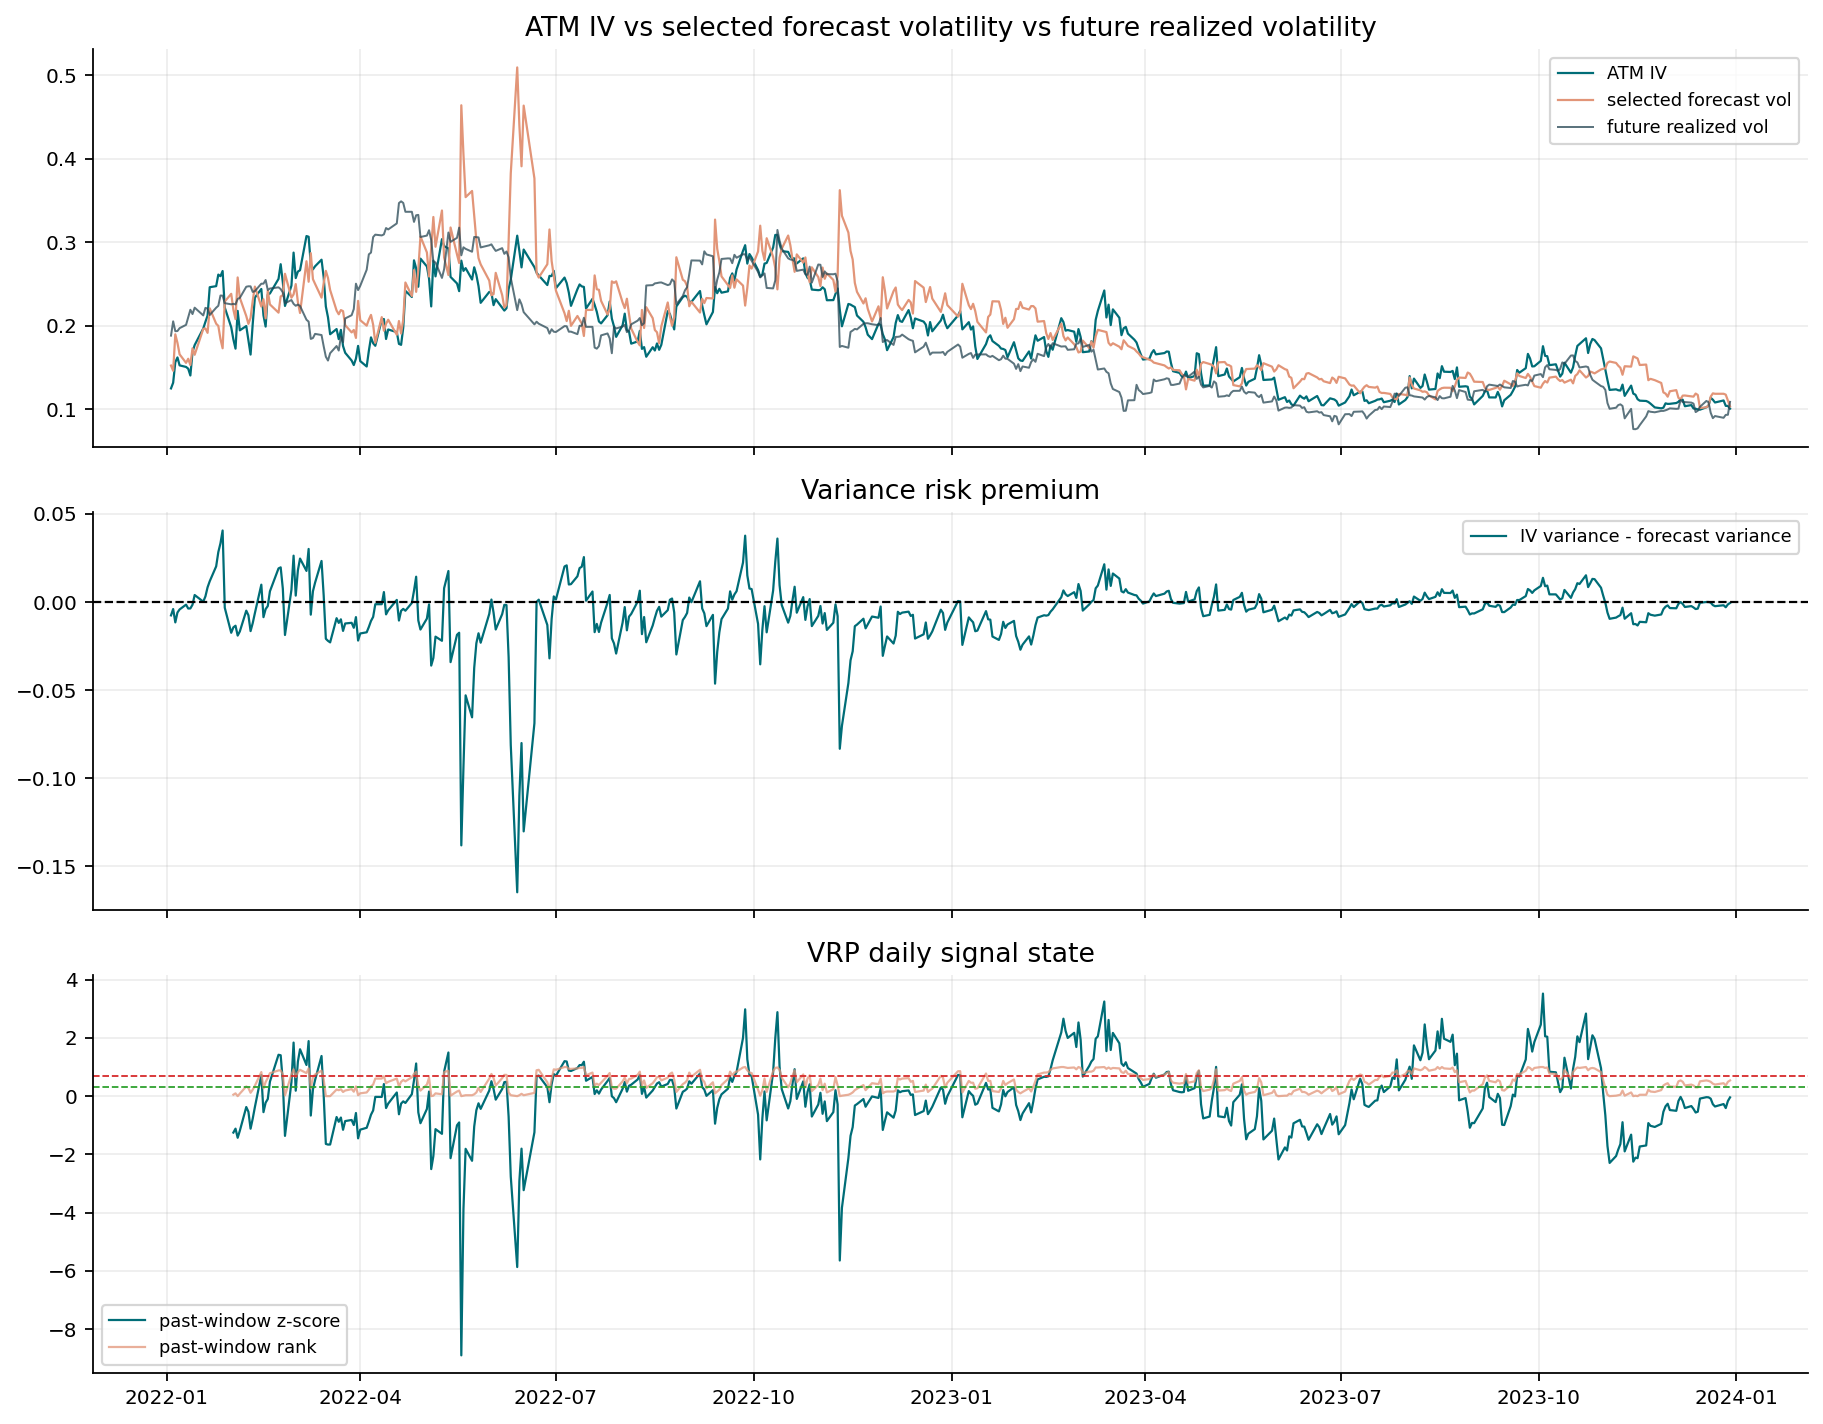

In [14]:
def regression_table_iv_forecast(vrp_panel):
    data = vrp_panel.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["future_realized_var_ann", "iv_var_ann", "forecast_var_ann"]).copy()
    specs = {
        "RV_future_on_IV_var": ["iv_var_ann"],
        "RV_future_on_forecast_var": ["forecast_var_ann"],
        "RV_future_on_both": ["iv_var_ann", "forecast_var_ann"]}
    rows = []
    for name, cols in specs.items():
        z = data[["future_realized_var_ann", *cols]].dropna()
        if len(z) < 30:
            continue
        X = sm.add_constant(z[cols])
        res = sm.OLS(z["future_realized_var_ann"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        row = {"model": name, "r2": float(res.rsquared), "n_obs": int(len(z))}
        for param in res.params.index:
            row[f"{param}_coef"] = float(res.params[param])
            row[f"{param}_t"] = float(res.tvalues[param])
            row[f"{param}_p"] = float(res.pvalues[param])
        rows.append(row)
    return pd.DataFrame(rows)

df_iv_forecast_regression = regression_table_iv_forecast(vrp_panel)
display(df_iv_forecast_regression)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.0), sharex=True)
axes[0].plot(vrp_panel["date"], vrp_panel["atm_iv_mid"], lw=1.0, label="ATM IV")
axes[0].plot(vrp_panel["date"], vrp_panel["forecast_vol_ann"], lw=1.0, label="selected forecast vol")
axes[0].plot(vrp_panel["date"], vrp_panel["future_realized_vol_ann"], lw=0.9, alpha=0.75, label="future realized vol")
axes[0].set_title("ATM IV vs selected forecast volatility vs future realized volatility")
axes[0].legend(loc="best")

axes[1].plot(vrp_panel["date"], vrp_panel["vrp_var"], lw=1.0, label="IV variance - forecast variance")
axes[1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1].set_title("Variance risk premium")
axes[1].legend(loc="best")

axes[2].plot(vrp_panel["date"], vrp_panel["vrp_z"], lw=1.0, label="past-window z-score")
axes[2].plot(vrp_panel["date"], vrp_panel["vrp_rank"], lw=1.0, alpha=0.75, label="past-window rank")
axes[2].axhline(0.30, lw=0.8, ls="--", c="tab:green")
axes[2].axhline(0.70, lw=0.8, ls="--", c="tab:red")
axes[2].set_title("VRP daily signal state")
axes[2].legend(loc="best")
plt.tight_layout()
plt.show()


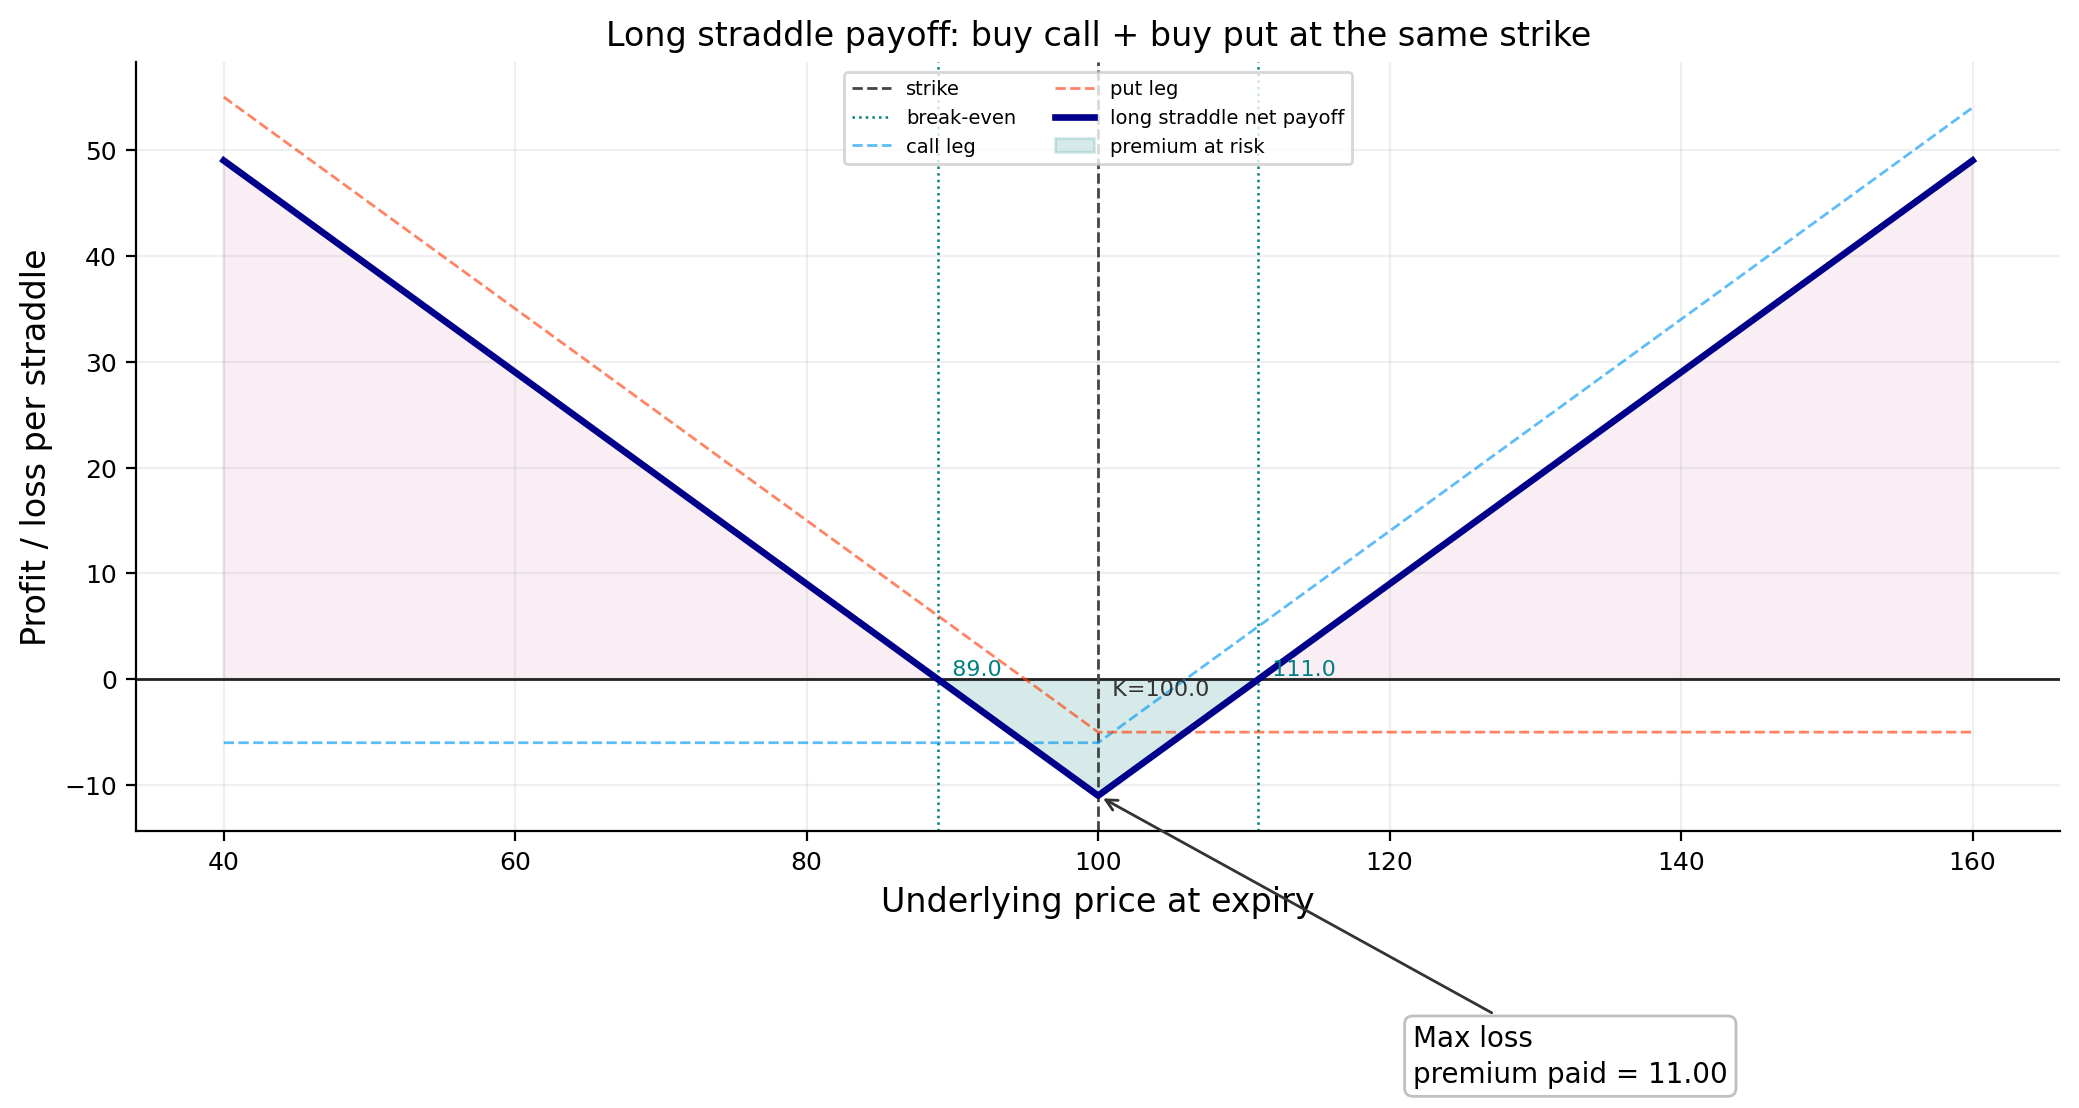

In [15]:
from quantfinlab.plotting.diagrams import plot_straddle_payoff

fig, ax = plot_straddle_payoff(
    spot=100.0,
    strike=100.0,
    call_premium=6.0,
    put_premium=5.0,
    side="long",
    title="Long straddle payoff: buy call + buy put at the same strike")
plt.show()


In [16]:
initial_nav = 1_000_000
contract_multiplier = 100
holding_days = 5
allow_overlap = False
fractional_units = False
max_units = None
long_premium_budget_frac = 0.005
short_margin_spot_frac = 0.15
short_margin_budget_frac = 0.02
max_short_notional_frac = 1.0
max_exit_lag = 2

def prepare_straddle_quote_book(raw_chain):
    book = raw_chain.copy()
    book["date"] = pd.to_datetime(book["quote_date"], errors="coerce").dt.normalize()
    book["expiry"] = pd.to_datetime(book["expire_date"], errors="coerce").dt.normalize()
    book["spot"] = pd.to_numeric(book["underlying_last"], errors="coerce")
    book["strike"] = pd.to_numeric(book["strike"], errors="coerce")
    for col in ["c_bid", "c_ask", "p_bid", "p_ask"]:
        book[col] = pd.to_numeric(book[col], errors="coerce")
    book["call_mid"] = 0.5 * (book["c_bid"] + book["c_ask"])
    book["put_mid"] = 0.5 * (book["p_bid"] + book["p_ask"])
    book["dte_calendar"] = (book["expiry"] - book["date"]).dt.total_seconds() / 86400.0
    valid = (
        book["date"].notna()
        & book["expiry"].notna()
        & (book["strike"] > 0)
        & (book["spot"] > 0)
        & (book["c_bid"] >= 0)
        & (book["p_bid"] >= 0)
        & (book["c_ask"] >= book["c_bid"])
        & (book["p_ask"] >= book["p_bid"])
        & (book["call_mid"] > 0)
        & (book["put_mid"] > 0)
    )
    cols = ["date", "expiry", "strike", "spot", "dte_calendar", "c_bid", "c_ask", "p_bid", "p_ask", "call_mid", "put_mid"]
    out = book.loc[valid, cols].copy()
    out["strike_key"] = out["strike"].round(8)
    return out.sort_values(["expiry", "strike_key", "date"]).reset_index(drop=True)

quote_book = prepare_straddle_quote_book(df_chain)
market_dates = pd.DatetimeIndex(df_market["trade_date"]).normalize()

def find_exit_quote(book, entry_date, target_exit_date, expiry, strike, max_exit_lag=2):
    entry_date = pd.Timestamp(entry_date).normalize()
    target_exit_date = pd.Timestamp(target_exit_date).normalize()
    expiry = pd.Timestamp(expiry).normalize()
    strike_key = round(float(strike), 8)
    subset = book[
        (book["expiry"] == expiry)
        & (book["strike_key"] == strike_key)
        & (book["date"] > entry_date)
        & (book["date"] >= target_exit_date)
    ].copy()
    if subset.empty:
        return None, "missing_exit_contract"
    dates = pd.DatetimeIndex(sorted(subset["date"].unique()))
    pos = dates.searchsorted(target_exit_date, side="left")
    if pos >= len(dates):
        return None, "missing_exit_within_lag"
    exit_date = pd.Timestamp(dates[pos]).normalize()
    quote_dates = pd.DatetimeIndex(sorted(book["date"].dropna().unique()))
    target_rank = quote_dates.searchsorted(target_exit_date, side="left")
    exit_rank = quote_dates.searchsorted(exit_date, side="left")
    if exit_rank - target_rank > max_exit_lag:
        return None, "missing_exit_within_lag"
    rows = subset[subset["date"] == exit_date].sort_values("date")
    return rows.iloc[0], "exact_exit" if exit_date == target_exit_date else "nearest_later_exit"

def size_long_units(nav, call_ask, put_ask, budget_frac=long_premium_budget_frac, fractional_units=fractional_units, max_units=max_units):
    unit_premium = (float(call_ask) + float(put_ask)) * contract_multiplier
    if not np.isfinite(unit_premium) or unit_premium <= 0:
        return 0.0, unit_premium, "invalid_long_premium"
    units = float(nav) * float(budget_frac) / unit_premium
    units = units if fractional_units else np.floor(units)
    if max_units is not None:
        units = min(units, float(max_units))
    return float(units), float(unit_premium), "" if units > 0 else "long_budget_too_small"

def size_short_units(nav, spot, call_mid, put_mid, short_margin_budget_frac=short_margin_budget_frac, max_short_notional_frac=max_short_notional_frac, fractional_units=fractional_units, max_units=max_units):
    unit_margin_proxy = contract_multiplier * (short_margin_spot_frac * float(spot) + float(call_mid) + float(put_mid))
    unit_notional = contract_multiplier * float(spot)
    if not np.isfinite(unit_margin_proxy) or unit_margin_proxy <= 0 or not np.isfinite(unit_notional) or unit_notional <= 0:
        return 0.0, unit_margin_proxy, unit_notional, "invalid_short_cap"
    units_margin = float(nav) * float(short_margin_budget_frac) / unit_margin_proxy
    units_notional = float(nav) * float(max_short_notional_frac) / unit_notional
    units = min(units_margin, units_notional)
    units = units if fractional_units else np.floor(units)
    if max_units is not None:
        units = min(units, float(max_units))
    return float(units), float(unit_margin_proxy), float(unit_notional), "" if units > 0 else "short_cap_too_small"

def cheap_signal(row, cheap_rank=0.30, cheap_z=-0.50, require_forecast_gt_iv=False):
    rank_hit = pd.notna(row.get("vrp_rank")) and row.get("vrp_rank") <= cheap_rank
    z_hit = pd.notna(row.get("vrp_z")) and row.get("vrp_z") <= cheap_z
    extra_ok = True if not require_forecast_gt_iv else row.get("forecast_vol_ann", np.nan) > row.get("atm_iv_mid", np.nan)
    return bool((rank_hit or z_hit) and extra_ok)

def rich_signal(row, rich_rank=0.70, rich_z=0.50, require_iv_gt_forecast=False):
    rank_hit = pd.notna(row.get("vrp_rank")) and row.get("vrp_rank") >= rich_rank
    z_hit = pd.notna(row.get("vrp_z")) and row.get("vrp_z") >= rich_z
    extra_ok = True if not require_iv_gt_forecast else row.get("atm_iv_mid", np.nan) > row.get("forecast_vol_ann", np.nan)
    return bool((rank_hit or z_hit) and extra_ok)

def decide_strategy(row, strategy, cheap_rank=0.30, rich_rank=0.70, cheap_z=-0.50, rich_z=0.50):
    cheap = cheap_signal(row, cheap_rank=cheap_rank, cheap_z=cheap_z)
    rich = rich_signal(row, rich_rank=rich_rank, rich_z=rich_z)
    if strategy == "AlwaysLongStraddle":
        return "long"
    if strategy == "LongCheapConvexity":
        return "long" if cheap else "cash"
    if strategy == "ShortRichVolatility":
        return "short" if rich else "cash"
    if strategy == "TwoSidedVRPSwitcher":
        if cheap and not rich:
            return "long"
        if rich and not cheap:
            return "short"
        if cheap and rich:
            return "long" if row.get("vrp_var", np.nan) < 0 else "short"
        return "cash"
    raise ValueError(f"Unknown strategy {strategy}")


In [17]:
def backtest_straddle_strategy(
    strategy_name, signals, quote_book, market_dates,
    cheap_rank=0.30, rich_rank=0.70,cheap_z=-0.50,
    rich_z=0.50, long_budget_frac=long_premium_budget_frac,
    short_budget_frac=short_margin_budget_frac,
    short_notional_frac=max_short_notional_frac, initial_nav=initial_nav):

    signals = signals.sort_values("date").reset_index(drop=True)
    nav = float(initial_nav)
    open_until = pd.Timestamp.min
    trades = []
    skipped = []
    market_dates = pd.DatetimeIndex(market_dates).normalize()
    for _, row in signals.iterrows():
        entry_date = pd.Timestamp(row["date"]).normalize()
        if (not allow_overlap) and entry_date <= open_until:
            skipped.append({"strategy": strategy_name, "date": entry_date, "skip_reason": "open_position"})
            continue
        side = decide_strategy(row, strategy_name, cheap_rank=cheap_rank, rich_rank=rich_rank, cheap_z=cheap_z, rich_z=rich_z)
        if side == "cash":
            skipped.append({"strategy": strategy_name, "date": entry_date, "skip_reason": "no_signal"})
            continue
        if entry_date not in market_dates:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": "missing_market_date"})
            continue
        pos = market_dates.get_loc(entry_date)
        if pos + holding_days >= len(market_dates):
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": "not_enough_future_dates"})
            continue
        target_exit_date = pd.Timestamp(market_dates[pos + holding_days]).normalize()
        exit_row, exit_flag = find_exit_quote(quote_book, entry_date, target_exit_date, row["expiry"], row["strike"], max_exit_lag=max_exit_lag)
        if exit_row is None:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": exit_flag})
            continue

        call_bid, call_ask = float(row["call_bid"]), float(row["call_ask"])
        put_bid, put_ask = float(row["put_bid"]), float(row["put_ask"])
        call_mid, put_mid = float(row["call_mid"]), float(row["put_mid"])
        if side == "long":
            long_fractional_units = bool(fractional_units or strategy_name == "AlwaysLongStraddle")
            units, unit_cap, skip_reason = size_long_units(
                nav,
                call_ask,
                put_ask,
                budget_frac=long_budget_frac,
                fractional_units=long_fractional_units)
            entry_call_price, entry_put_price = call_ask, put_ask
            exit_call_price, exit_put_price = float(exit_row["c_bid"]), float(exit_row["p_bid"])
            entry_cashflow = -units * (entry_call_price + entry_put_price) * contract_multiplier
            exit_cashflow = units * (exit_call_price + exit_put_price) * contract_multiplier
            margin_proxy = np.nan
            cap_used = units * unit_cap
            premium_paid_or_received = abs(entry_cashflow)
        else:
            units, unit_margin, unit_notional, skip_reason = size_short_units(
                nav,
                float(row["spot"]),
                call_mid,
                put_mid,
                short_margin_budget_frac=short_budget_frac,
                max_short_notional_frac=short_notional_frac)
            entry_call_price, entry_put_price = call_bid, put_bid
            exit_call_price, exit_put_price = float(exit_row["c_ask"]), float(exit_row["p_ask"])
            entry_cashflow = units * (entry_call_price + entry_put_price) * contract_multiplier
            exit_cashflow = -units * (exit_call_price + exit_put_price) * contract_multiplier
            margin_proxy = units * unit_margin
            cap_used = margin_proxy
            premium_paid_or_received = entry_cashflow
        if units <= 0:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": skip_reason})
            continue
        net_pnl = entry_cashflow + exit_cashflow
        nav += net_pnl
        exit_date = pd.Timestamp(exit_row["date"]).normalize()
        open_until = exit_date
        entry_spread_proxy = 0.5 * ((call_ask - call_bid) + (put_ask - put_bid)) * units * contract_multiplier
        exit_spread_proxy = 0.5 * ((float(exit_row["c_ask"]) - float(exit_row["c_bid"])) + (float(exit_row["p_ask"]) - float(exit_row["p_bid"]))) * units * contract_multiplier
        notional_exposure = units * float(row["spot"]) * contract_multiplier
        denom = abs(entry_cashflow) if side == "long" else margin_proxy
        trades.append({
            "strategy": strategy_name,
            "side": side,
            "entry_date": entry_date,
            "exit_date": exit_date,
            "expiry": pd.Timestamp(row["expiry"]).normalize(),
            "strike": float(row["strike"]),
            "dte_entry": float(row["dte_calendar"]),
            "dte_exit": float(exit_row["dte_calendar"]),
            "spot_entry": float(row["spot"]),
            "spot_exit": float(exit_row["spot"]),
            "atm_iv_entry": float(row["atm_iv_mid"]),
            "forecast_vol_entry": float(row["forecast_vol_ann"]),
            "forecast_var_entry": float(row["forecast_var_ann"]),
            "vrp_var": float(row["vrp_var"]),
            "vrp_z": float(row["vrp_z"]) if pd.notna(row["vrp_z"]) else np.nan,
            "vrp_rank": float(row["vrp_rank"]) if pd.notna(row["vrp_rank"]) else np.nan,
            "selected_model": row["selected_model"],
            "units": float(units),
            "contract_multiplier": float(contract_multiplier),
            "entry_call_price": entry_call_price,
            "entry_put_price": entry_put_price,
            "exit_call_price": exit_call_price,
            "exit_put_price": exit_put_price,
            "entry_cashflow": float(entry_cashflow),
            "exit_cashflow": float(exit_cashflow),
            "gross_pnl": float(net_pnl),
            "net_pnl": float(net_pnl),
            "premium_paid_or_received": float(premium_paid_or_received),
            "margin_proxy": float(margin_proxy) if np.isfinite(margin_proxy) else np.nan,
            "notional_exposure": float(notional_exposure),
            "cap_used": float(cap_used),
            "spread_cost_proxy": float(entry_spread_proxy + exit_spread_proxy),
            "return_on_premium_or_margin": float(net_pnl / denom) if denom and np.isfinite(denom) else np.nan,
            "entry_flag": "entered",
            "exit_flag": exit_flag,
            "skip_reason": ""})
    trades_df = pd.DataFrame(trades)
    skipped_df = pd.DataFrame(skipped)
    start_date = pd.Timestamp(signals["date"].min()).normalize()
    end_date = pd.Timestamp(signals["date"].max()).normalize()
    if not trades_df.empty and "exit_date" in trades_df:
        end_date = max(end_date, pd.Timestamp(trades_df["exit_date"].max()).normalize())
    eq_dates = market_dates[(market_dates >= start_date) & (market_dates <= end_date)]
    equity = pd.DataFrame({"date": eq_dates})
    if trades_df.empty:
        equity["strategy_pnl"] = 0.0
        equity["nav"] = float(initial_nav)
    else:
        pnl_by_date = trades_df.groupby("exit_date")["net_pnl"].sum()
        equity["strategy_pnl"] = equity["date"].map(pnl_by_date).fillna(0.0)
        equity["nav"] = float(initial_nav) + equity["strategy_pnl"].cumsum()
    equity["running_max_nav"] = equity["nav"].cummax()
    equity["drawdown"] = equity["nav"] / equity["running_max_nav"] - 1.0
    equity["strategy"] = strategy_name
    return trades_df, equity, skipped_df

def run_overlay_suite(signals, cheap_rank=0.30, rich_rank=0.70, cheap_z=-0.50, rich_z=0.50, 
                      long_budget_frac=long_premium_budget_frac, 
                      short_budget_frac=short_margin_budget_frac, short_notional_frac=max_short_notional_frac):
    strategy_names = ["AlwaysLongStraddle", "LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"]
    return {
        name: backtest_straddle_strategy(name, signals, quote_book, market_dates,
                                         cheap_rank=cheap_rank, rich_rank=rich_rank,
                                         cheap_z=cheap_z, rich_z=rich_z,
                                         long_budget_frac=long_budget_frac,
                                         short_budget_frac=short_budget_frac,
                                         short_notional_frac=short_notional_frac)
        for name in strategy_names}

backtests_default = run_overlay_suite(vrp_panel)

def summarize_strategy_backtests(backtests, initial_nav=initial_nav):
    rows = []
    for name, (trades, equity, skipped) in backtests.items():
        nav = equity["nav"] if not equity.empty else pd.Series([initial_nav])
        daily_ret = nav.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        downside = daily_ret[daily_ret < 0]
        row = {
            "strategy": name,
            "total_net_pnl": float(nav.iloc[-1] - initial_nav),
            "return_on_initial_nav": float(nav.iloc[-1] / initial_nav - 1.0),
            "ann_vol": float(daily_ret.std(ddof=1) * np.sqrt(annualization)) if len(daily_ret) > 2 else np.nan,
            "sharpe": float(daily_ret.mean() / daily_ret.std(ddof=1) * np.sqrt(annualization)) if len(daily_ret) > 2 and daily_ret.std(ddof=1) > 0 else np.nan,
            "sortino": float(daily_ret.mean() / downside.std(ddof=1) * np.sqrt(annualization)) if len(downside) > 2 and downside.std(ddof=1) > 0 else np.nan,
            "max_drawdown": float(equity["drawdown"].min()) if "drawdown" in equity else np.nan,
            "n_trades": int(len(trades)),
            "n_skipped": int(len(skipped))}
        
        if not trades.empty:
            row.update({
                "hit_rate": float((trades["net_pnl"] > 0).mean()),
                "avg_trade_pnl": float(trades["net_pnl"].mean()),
                "median_trade_pnl": float(trades["net_pnl"].median()),
                "best_trade": float(trades["net_pnl"].max()),
                "worst_trade": float(trades["net_pnl"].min()),
                "avg_units": float(trades["units"].mean()),
                "avg_premium_paid_or_received": float(trades["premium_paid_or_received"].mean()),
                "avg_margin_proxy": float(trades["margin_proxy"].mean()),
                "avg_notional_exposure": float(trades["notional_exposure"].mean()),
                "total_spread_cost_proxy": float(trades["spread_cost_proxy"].sum()),
                "avg_vrp_rank": float(trades["vrp_rank"].mean()),
                "avg_vrp_z": float(trades["vrp_z"].mean())})
        rows.append(row)
    return pd.DataFrame(rows)

summary_default = summarize_strategy_backtests(backtests_default)

vrp_strategy_counts = summary_default[summary_default["strategy"].isin(["LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"])]["n_trades"]
if len(vrp_strategy_counts) and (vrp_strategy_counts < 20).any():
    print("Warning: at least one VRP strategy has fewer than 20 trades under the default integer-contract caps.")
    print("Running documented sensitivity: cheap rank <= 0.40, rich rank >= 0.60, with larger premium/margin caps.")
    backtests_sensitivity = run_overlay_suite(
        vrp_panel,
        cheap_rank=0.40,
        rich_rank=0.60,
        cheap_z=-0.35,
        rich_z=0.35,
        long_budget_frac=0.015,
        short_budget_frac=0.08,
        short_notional_frac=2.0)
    
    summary_sensitivity = summarize_strategy_backtests(backtests_sensitivity)
    display(summary_sensitivity)
    backtests_for_plots = backtests_sensitivity
    summary_for_plots = summary_sensitivity
else:
    backtests_for_plots = backtests_default
    summary_for_plots = summary_default


Running documented sensitivity: cheap rank <= 0.40, rich rank >= 0.60, with larger premium/margin caps.


,strategy,total_net_pnl,return_on_initial_nav,ann_vol,sharpe,sortino,max_drawdown,n_trades,n_skipped,hit_rate,...,median_trade_pnl,best_trade,worst_trade,avg_units,avg_premium_paid_or_received,avg_margin_proxy,avg_notional_exposure,total_spread_cost_proxy,avg_vrp_rank,avg_vrp_z
0,AlwaysLongStraddle,"-14,184.834091",-0.014185,0.017454,-0.403850,-0.464032,-0.038538,83,413,0.313253,...,-816.918423,"10,382.222078","-3,302.577234",0.918046,"15,052.141233",NaN,"388,832.663105","19,534.666808",0.494476,0.043766
1,LongCheapConvexity,"6,990.000000",0.006990,0.008769,0.404704,0.255385,-0.008429,18,478,0.500000,...,-245.000000,"8,810.000000","-3,060.000000",1.000000,"12,342.222222",NaN,"433,555.166667","4,635.000000",0.206349,-0.858637
2,ShortRichVolatility,"33,560.000000",0.033560,0.010002,1.668433,1.092442,-0.008355,41,455,0.731707,...,"1,580.000000","3,530.000000","-3,630.000000",1.000000,"17,399.756098","78,505.600000","406,955.219512","9,055.000000",0.788618,0.872876
3,TwoSidedVRPSwitcher,"24,520.000000",0.024520,0.012652,0.971285,0.832574,-0.008355,52,444,0.596154,...,925.000000,"8,810.000000","-3,670.000000",1.000000,"16,187.115385","78,536.142308","414,248.865385","11,360.000000",0.645604,0.446684


In [18]:
all_trades = pd.concat([trades for trades, _, _ in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()
all_equity = pd.concat([equity for _, equity, _ in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()

display(summary_for_plots)
if not all_trades.empty:
    trade_count_by_year = all_trades.assign(year=all_trades["entry_date"].dt.year).pivot_table(index="year", columns="strategy", values="net_pnl", aggfunc="count", fill_value=0)
    display(trade_count_by_year)

    all_trades["vrp_decile"] = pd.cut(all_trades["vrp_rank"], bins=np.linspace(0, 1, 11), include_lowest=True)
    pnl_by_decile = (
        all_trades.dropna(subset=["vrp_decile"])
        .groupby(["strategy", "vrp_decile"], observed=True)
        .agg(n_trades=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean"), hit_rate=("net_pnl", lambda x: float((x > 0).mean())))
        .reset_index())

    side_breakdown = all_trades.groupby(["strategy", "side"]).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean")).reset_index()

    regime_edges = [-np.inf, 0.30, 0.70, np.inf]
    regime_labels = ["cheap VRP", "neutral VRP", "rich VRP"]
    all_trades["vrp_regime"] = pd.cut(all_trades["vrp_rank"], bins=regime_edges, labels=regime_labels)
    regime_counts = all_trades.groupby(["strategy", "vrp_regime"], observed=True).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum")).reset_index()
    display(regime_counts)
else:
    print("No strategy trades were generated; inspect skipped reasons below.")
    

,strategy,total_net_pnl,return_on_initial_nav,ann_vol,sharpe,sortino,max_drawdown,n_trades,n_skipped,hit_rate,...,median_trade_pnl,best_trade,worst_trade,avg_units,avg_premium_paid_or_received,avg_margin_proxy,avg_notional_exposure,total_spread_cost_proxy,avg_vrp_rank,avg_vrp_z
0,AlwaysLongStraddle,"-14,184.834091",-0.014185,0.017454,-0.403850,-0.464032,-0.038538,83,413,0.313253,...,-816.918423,"10,382.222078","-3,302.577234",0.918046,"15,052.141233",NaN,"388,832.663105","19,534.666808",0.494476,0.043766
1,LongCheapConvexity,"6,990.000000",0.006990,0.008769,0.404704,0.255385,-0.008429,18,478,0.500000,...,-245.000000,"8,810.000000","-3,060.000000",1.000000,"12,342.222222",NaN,"433,555.166667","4,635.000000",0.206349,-0.858637
2,ShortRichVolatility,"33,560.000000",0.033560,0.010002,1.668433,1.092442,-0.008355,41,455,0.731707,...,"1,580.000000","3,530.000000","-3,630.000000",1.000000,"17,399.756098","78,505.600000","406,955.219512","9,055.000000",0.788618,0.872876
3,TwoSidedVRPSwitcher,"24,520.000000",0.024520,0.012652,0.971285,0.832574,-0.008355,52,444,0.596154,...,925.000000,"8,810.000000","-3,670.000000",1.000000,"16,187.115385","78,536.142308","414,248.865385","11,360.000000",0.645604,0.446684


strategy,AlwaysLongStraddle,LongCheapConvexity,ShortRichVolatility,TwoSidedVRPSwitcher
year,,,,
2022,42,0,15,15
2023,41,18,26,37


,strategy,vrp_regime,n,total_pnl
0,AlwaysLongStraddle,cheap VRP,27,"10,054.399208"
1,AlwaysLongStraddle,neutral VRP,26,"-3,533.964585"
2,AlwaysLongStraddle,rich VRP,26,"-26,353.754335"
3,LongCheapConvexity,cheap VRP,14,"10,060.000000"
4,LongCheapConvexity,neutral VRP,4,"-3,070.000000"
5,ShortRichVolatility,neutral VRP,15,"5,050.000000"
6,ShortRichVolatility,rich VRP,26,"28,510.000000"
7,TwoSidedVRPSwitcher,cheap VRP,10,"3,900.000000"
8,TwoSidedVRPSwitcher,neutral VRP,17,"4,940.000000"
9,TwoSidedVRPSwitcher,rich VRP,25,"15,680.000000"


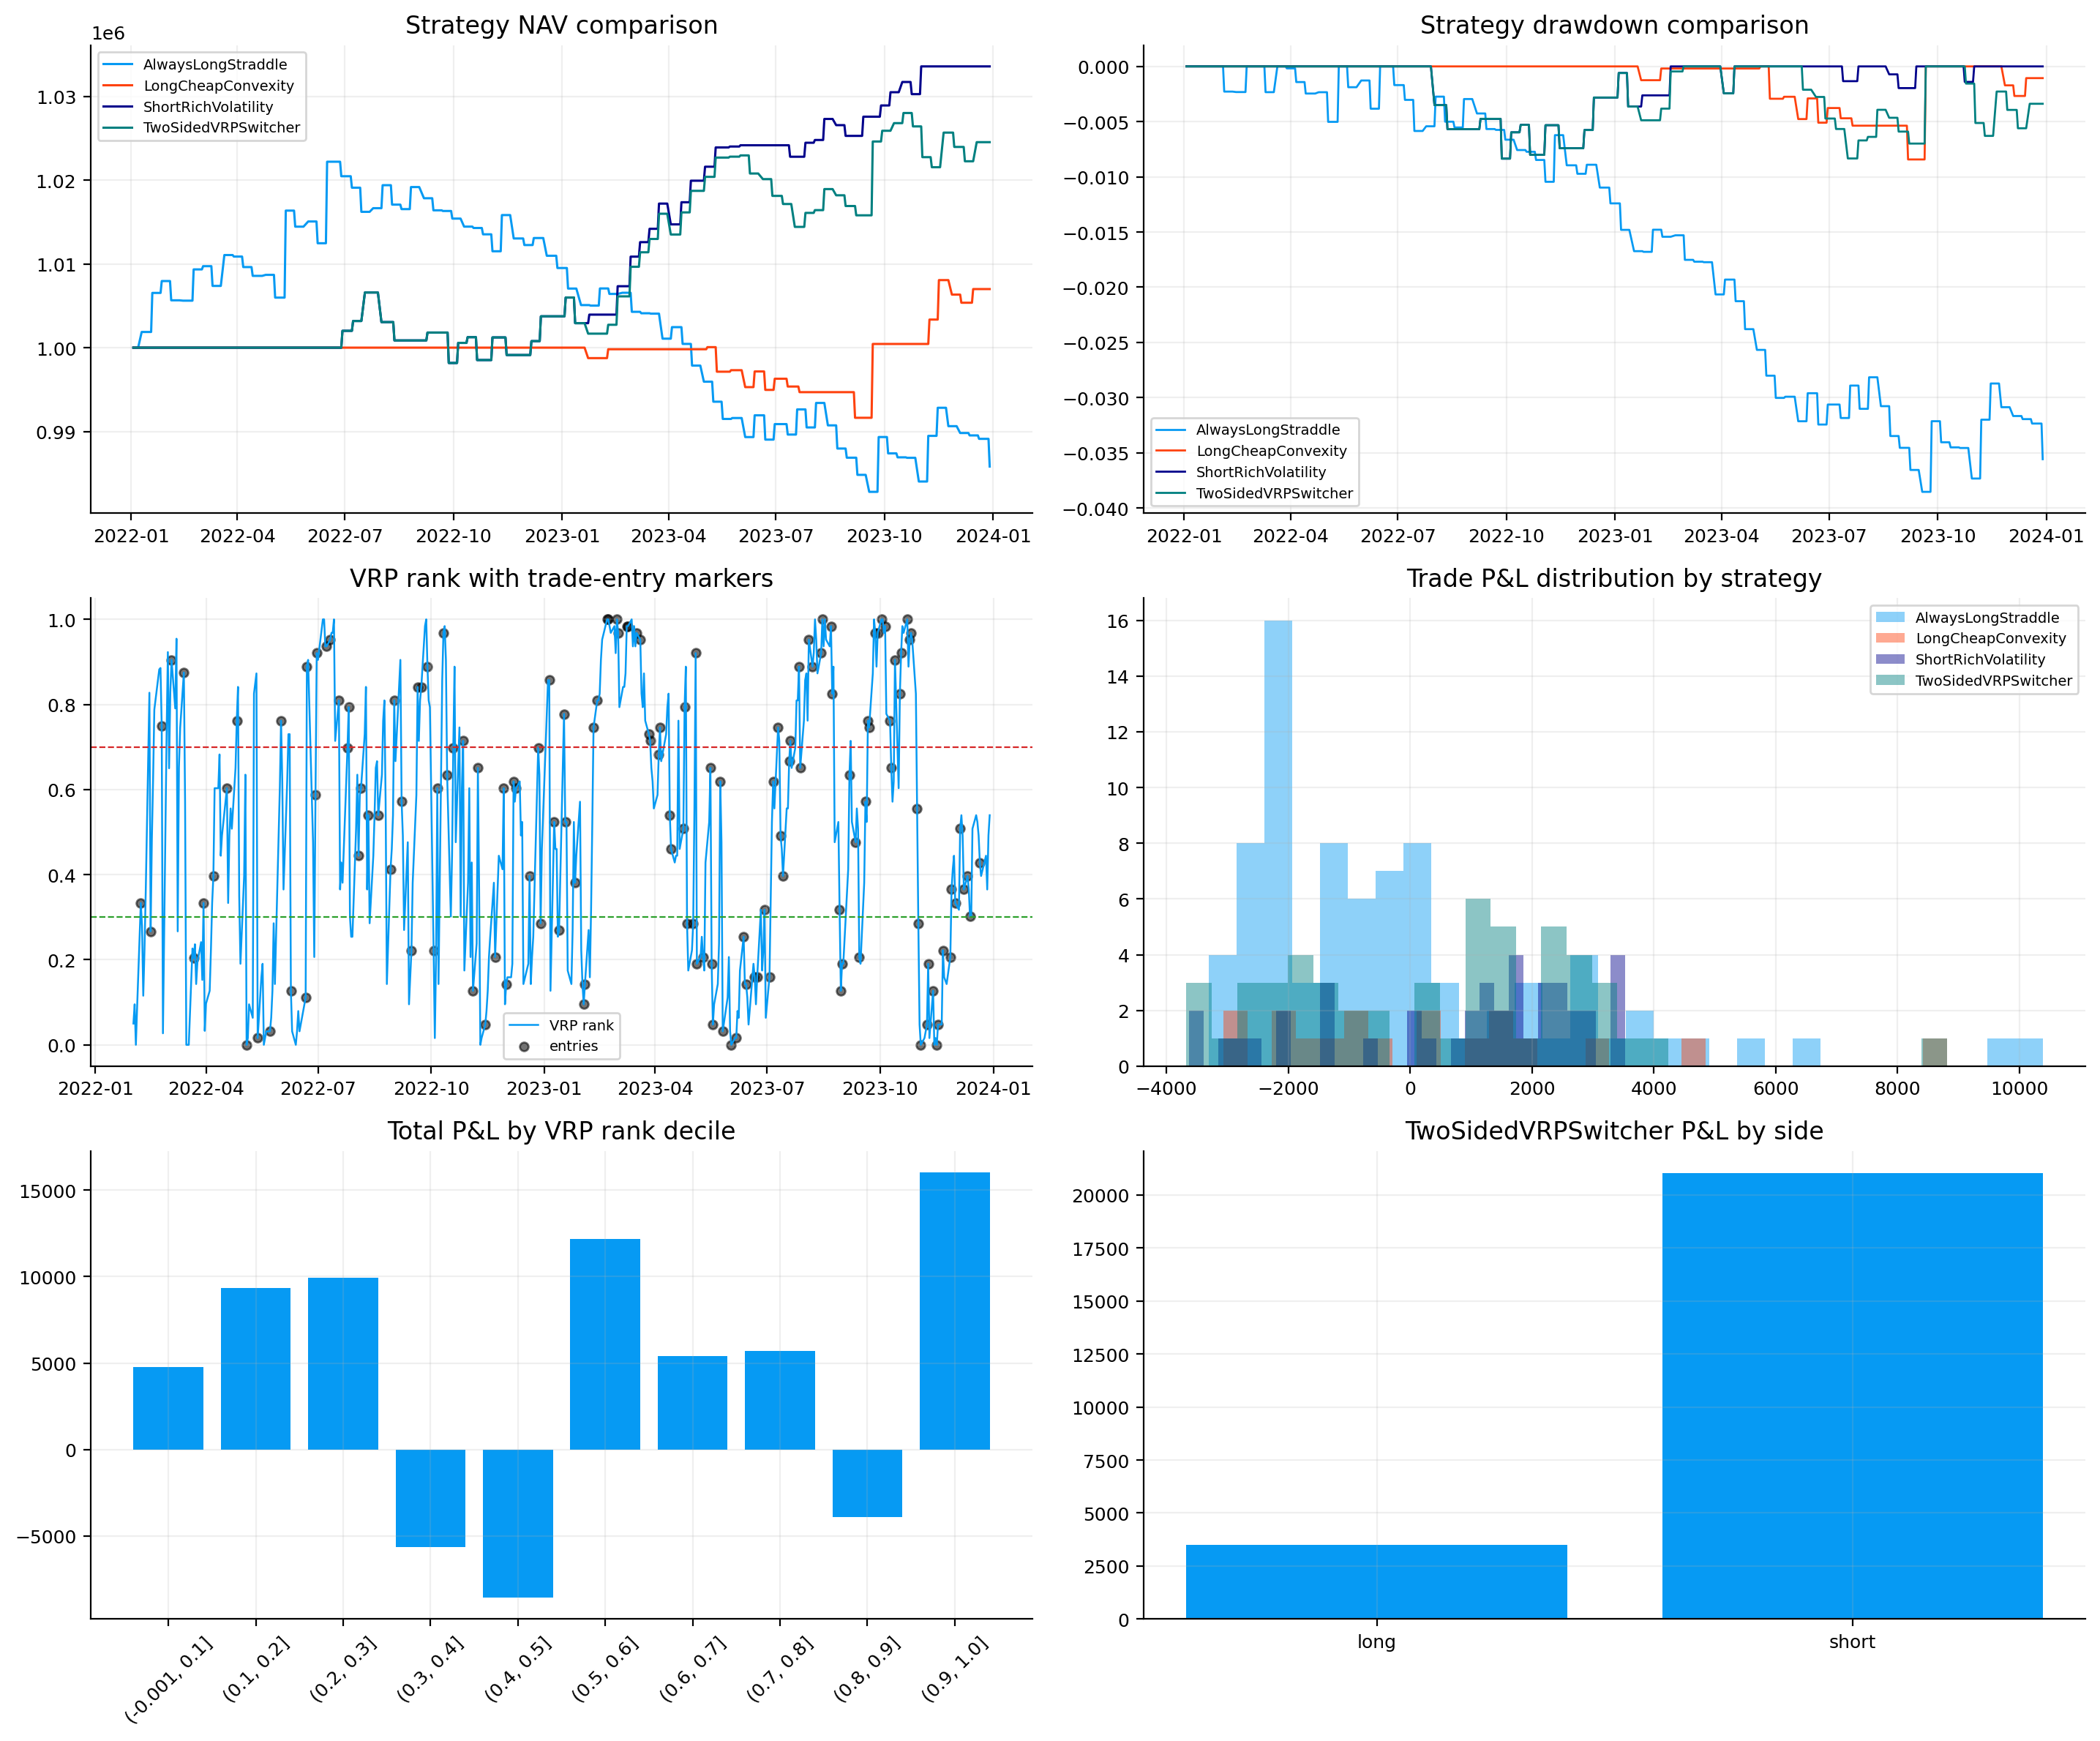

In [19]:
if not all_equity.empty:
    fig, axes = plt.subplots(3, 2, figsize=(14.5, 12.0))
    axes = axes.ravel()
    for name, g in all_equity.groupby("strategy"):
        axes[0].plot(g["date"], g["nav"], lw=1.1, label=name)
        axes[1].plot(g["date"], g["drawdown"], lw=1.0, label=name)
    axes[0].set_title("Strategy NAV comparison")
    axes[1].set_title("Strategy drawdown comparison")
    axes[0].legend(loc="best")
    axes[1].legend(loc="best")

    axes[2].plot(vrp_panel["date"], vrp_panel["vrp_rank"], lw=0.9, label="VRP rank")
    axes[2].axhline(0.30, ls="--", lw=0.8, c="tab:green")
    axes[2].axhline(0.70, ls="--", lw=0.8, c="tab:red")
    if not all_trades.empty:
        marker_dates = all_trades["entry_date"].dropna().unique()
        marker_panel = vrp_panel[vrp_panel["date"].isin(marker_dates)]
        axes[2].scatter(marker_panel["date"], marker_panel["vrp_rank"], s=18, c="black", alpha=0.55, label="entries")
    axes[2].set_title("VRP rank with trade-entry markers")
    axes[2].legend(loc="best")

    if not all_trades.empty:
        for name, g in all_trades.groupby("strategy"):
            axes[3].hist(g["net_pnl"], bins=30, alpha=0.45, label=name)
        axes[3].set_title("Trade P&L distribution by strategy")
        axes[3].legend(loc="best")

        decile_plot = all_trades.dropna(subset=["vrp_decile"]).groupby(["vrp_decile"], observed=True)["net_pnl"].sum()
        axes[4].bar([str(x) for x in decile_plot.index], decile_plot.to_numpy(dtype=float))
        axes[4].tick_params(axis="x", rotation=45)
        axes[4].set_title("Total P&L by VRP rank decile")

        switcher = all_trades[all_trades["strategy"] == "TwoSidedVRPSwitcher"]
        if not switcher.empty:
            side_pnl = switcher.groupby("side")["net_pnl"].sum()
            axes[5].bar(side_pnl.index.astype(str), side_pnl.to_numpy(dtype=float))
            axes[5].set_title("TwoSidedVRPSwitcher P&L by side")
        else:
            axes[5].axis("off")
    else:
        for ax in axes[3:]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


,step,rows,removed
0,raw wide rows,258234,NaN
1,long-form raw rows,258234,0.000000
2,long-form after schema normalization,258234,0.000000
3,long-form after positive price filter,218710,"39,524.000000"
4,long-form after bid/ask/spread filter,187179,"31,531.000000"
5,long-form after DTE filter,92808,"94,371.000000"
6,long-form after moneyness filter,56393,"36,415.000000"
7,long-form after ATM-pair selection,55591,802.000000
8,long-form final rows,55416,175.000000
9,price unit detected: usd,55416,0.000000


,model,qlike_rank
0,gjr11_normal,1.166667
1,egarch11_normal,2.333333
2,garch11_normal,3.000000
3,garch22_normal,4.166667
4,har_rv,5.000000
5,gjr11_student,5.666667
6,garch11_student,7.000000
7,garch22_student,7.666667


,model,horizon,qlike_var,rmse_var,mae_var,rmse_vol,mae_vol,corr_vol,n_obs
0,gjr11_normal,21,-3.149640,0.008296,0.006278,0.142169,0.107705,-0.199432,136
1,egarch11_normal,21,-3.147446,0.008439,0.006595,0.145306,0.112549,-0.141273,136
2,garch11_normal,21,-3.142783,0.008675,0.006439,0.147643,0.109804,-0.250013,136
3,garch22_normal,21,-3.133525,0.009102,0.006644,0.155017,0.112794,-0.379578,136
4,har_rv,21,-3.128213,0.008690,0.006730,0.147865,0.115867,-0.265453,136
5,gjr11_student,21,-2.994847,0.018170,0.015660,0.260631,0.229204,-0.054798,136
6,garch11_student,21,-2.981493,0.018867,0.015772,0.273932,0.228891,-0.263541,136
7,garch22_student,21,-2.971054,0.019325,0.016245,0.279759,0.234543,-0.282251,136


horizon,1,5,10,21,42,63
selected_model,,,,,,
egarch11_normal,74.000000,37.000000,30.000000,12.000000,21.000000,0.000000
garch11_normal,2.000000,0.000000,3.000000,15.000000,9.000000,0.000000
garch11_student,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
garch22_normal,0.000000,34.000000,5.000000,18.000000,26.000000,1.000000
gjr11_normal,45.000000,23.000000,30.000000,26.000000,50.000000,0.000000
har_rv,15.000000,42.000000,68.000000,64.000000,30.000000,135.000000


,scenario,strategy,cheap_rank,rich_rank,holding_days,total_net_pnl,return_on_initial_nav,max_drawdown,n_trades,hit_rate,avg_trade_pnl
0,loose,AlwaysLongStraddle,0.400000,0.700000,3,-2.592525,-0.002593,-0.008343,27,0.222222,-0.096019
1,loose,LongCheapConvexity,0.400000,0.700000,3,-6.755045,-0.006755,-0.006976,20,0.250000,-0.337752
2,loose,ShortRichVolatility,0.400000,0.700000,3,1.663766,0.001664,-0.000100,4,0.750000,0.415942
3,loose,TwoSidedVRPSwitcher,0.400000,0.700000,3,-0.929019,-0.000929,-0.005083,22,0.363636,-0.042228
4,base,AlwaysLongStraddle,0.350000,0.800000,3,-2.592525,-0.002593,-0.008343,27,0.222222,-0.096019
5,base,LongCheapConvexity,0.350000,0.800000,3,-5.002039,-0.005002,-0.005768,18,0.277778,-0.277891
6,base,ShortRichVolatility,0.350000,0.800000,3,0.052899,0.000053,-0.000100,2,0.500000,0.026449
7,base,TwoSidedVRPSwitcher,0.350000,0.800000,3,-4.850000,-0.004850,-0.005768,19,0.315789,-0.255263
8,strict,AlwaysLongStraddle,0.300000,0.900000,3,-2.592525,-0.002593,-0.008343,27,0.222222,-0.096019
9,strict,LongCheapConvexity,0.300000,0.900000,3,-2.198347,-0.002198,-0.006577,18,0.222222,-0.122130


,strategy,side,n,total_pnl,avg_pnl,avg_units
0,AlwaysLongStraddle,long,27,-2.592525,-0.096019,0.000585
1,LongCheapConvexity,long,11,-0.938869,-0.085352,0.000695
2,ShortRichVolatility,short,5,2.462878,0.492576,0.001118
3,TwoSidedVRPSwitcher,long,10,-0.274664,-0.027466,0.000682
4,TwoSidedVRPSwitcher,short,4,2.557684,0.639421,0.001036


,strategy,side,entry_date,exit_date,expiry,strike,units,net_pnl,vrp_rank,vrp_z,selected_model
0,AlwaysLongStraddle,long,2024-03-30,2024-04-02,2024-04-26,"71,000.000000",0.000450,-0.211639,NaN,NaN,har_rv
1,AlwaysLongStraddle,long,2024-04-03,2024-04-06,2024-04-26,"67,000.000000",0.000520,-1.511337,NaN,NaN,har_rv
2,AlwaysLongStraddle,long,2024-04-12,2024-04-15,2024-05-03,"72,000.000000",0.000553,0.373478,NaN,NaN,har_rv
3,AlwaysLongStraddle,long,2024-04-17,2024-04-20,2024-05-31,"65,000.000000",0.000402,-0.316612,0.117647,-1.124192,garch11_normal
4,AlwaysLongStraddle,long,2024-04-21,2024-04-24,2024-05-31,"66,000.000000",0.000406,-0.690472,0.333333,-0.513674,garch11_normal
5,AlwaysLongStraddle,long,2024-04-25,2024-04-28,2024-05-31,"65,000.000000",0.000514,-0.841136,0.000000,-2.241575,garch11_normal
6,AlwaysLongStraddle,long,2024-04-29,2024-05-02,2024-05-31,"62,000.000000",0.000613,0.087032,0.068966,-1.958578,garch22_normal
7,AlwaysLongStraddle,long,2024-05-03,2024-05-06,2024-05-31,"60,000.000000",0.000701,0.631579,0.000000,-1.905175,garch11_normal
8,AlwaysLongStraddle,long,2024-05-07,2024-05-10,2024-05-31,"63,000.000000",0.000723,-0.899662,0.081081,-1.398879,garch11_normal
9,AlwaysLongStraddle,long,2024-05-16,2024-05-19,2024-06-28,"65,000.000000",0.000483,-0.089335,0.377778,-0.798852,garch22_normal


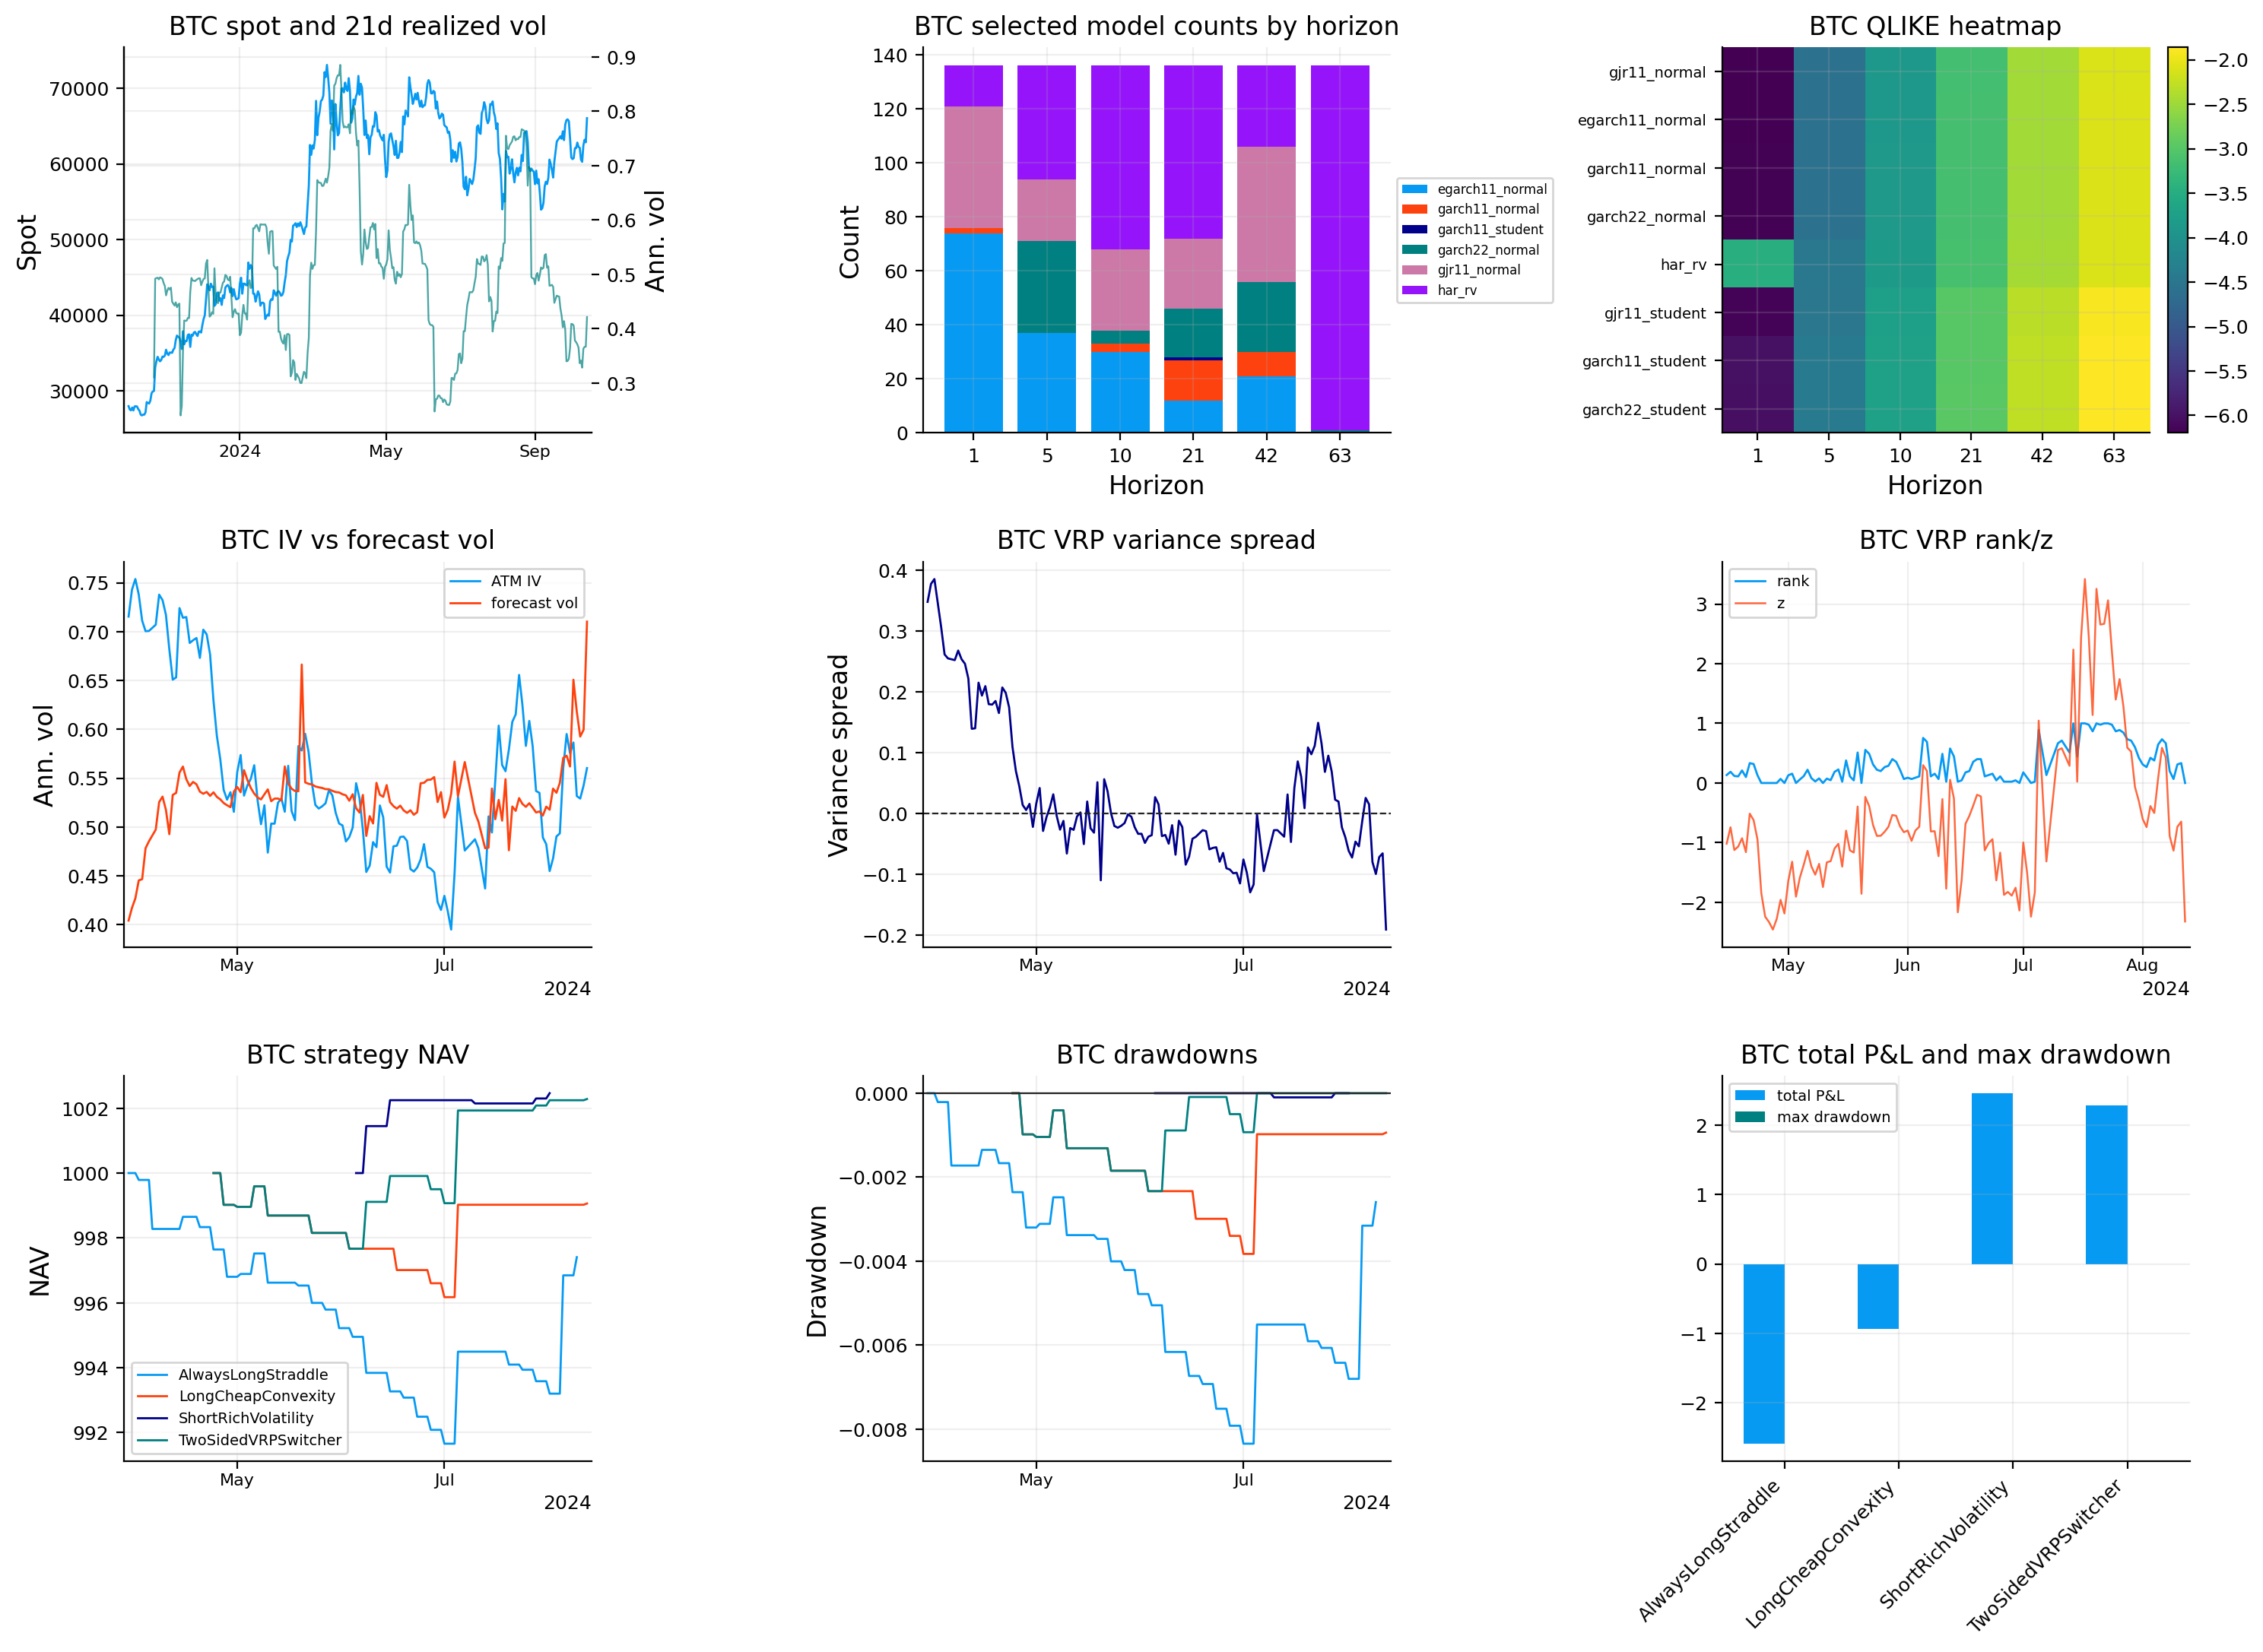

In [20]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


from quantfinlab.options.quote_cleaning import (
    convert_quotes_to_usd_equivalent,
    detect_option_price_unit,
    ensure_option_mid_quotes,
    normalize_option_quote_schema)
from quantfinlab.options.diagnostics import build_atm_iv_panel_from_option_quotes as build_library_atm_iv_panel
from quantfinlab.volatility.forecasting import rolling_arch_forecasts_weekly, score_forecasts_by_model, select_forecast_by_rolling_loss
from quantfinlab.volatility.har import rolling_har_forecasts
from quantfinlab.volatility.vrp import compute_vrp_panel
from quantfinlab.backtest.overlays import backtest_straddle_overlay, summarize_overlay_trades
import quantfinlab.plotting.volatility as vol_plots

horizons = (1, 5, 10, 21, 42, 63)
annualization = 365.25
eps = 1e-12
btc_option_path = r"..\data\btc_deribit_optiondx_2024_01_09.parquet"
btc_spot_path = r"..\data\btc_usd_yfinance_2023_10_01_2024_10_15.csv"

btc_options_raw = pd.read_parquet(btc_option_path)
btc_spot_raw = pd.read_csv(btc_spot_path)
btc_spot_data = btc_spot_raw.copy()
btc_spot_data.columns = [str(c).strip().lower().replace(" ", "_") for c in btc_spot_data.columns]
if "date" not in btc_spot_data.columns:
    raise ValueError("BTC spot file must contain a date column.")
btc_spot_data["date"] = pd.to_datetime(btc_spot_data["date"], errors="coerce").dt.normalize()
btc_price_col = "adj_close" if "adj_close" in btc_spot_data.columns else "close" if "close" in btc_spot_data.columns else None
if btc_price_col is None:
    btc_numeric_cols = btc_spot_data.select_dtypes(include=[np.number]).columns
    if len(btc_numeric_cols) == 0:
        raise ValueError("BTC spot file has no numeric price column.")
    btc_price_col = btc_numeric_cols[0]
btc_spot_data[btc_price_col] = pd.to_numeric(btc_spot_data[btc_price_col], errors="coerce")
btc_spot = (
    btc_spot_data.dropna(subset=["date", btc_price_col])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .set_index("date")[btc_price_col]
    .astype(float)
)
btc_spot = btc_spot[btc_spot > 0].rename("btc_spot")

btc_returns = np.log(btc_spot / btc_spot.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
btc_signal_start = btc_returns.index.min() + pd.Timedelta(days=120)
btc_options_norm = normalize_option_quote_schema(btc_options_raw, underlying_default="BTC")
btc_options_norm = ensure_option_mid_quotes(btc_options_norm)
btc_unit_before = detect_option_price_unit(btc_options_norm)
btc_options_usd = convert_quotes_to_usd_equivalent(btc_options_norm, unit="auto")
btc_unit_after = detect_option_price_unit(btc_options_usd)


btc_iv_all = build_library_atm_iv_panel(btc_options_usd, rates=None, constant_rate=0.0,
                                        min_dte=7, max_dte=90, moneyness_range=(0.75, 1.25),
                                        max_relative_spread=0.35, closest_atm_pairs=30,
                                        min_pairs_per_expiry=4, underlying_default="BTC")
if btc_iv_all.empty:
    raise RuntimeError("BTC ATM IV panel is empty after cleaning.")
btc_iv_daily = (
    btc_iv_all[(btc_iv_all["dte_calendar"] >= 14) & (btc_iv_all["dte_calendar"] <= 45)]
    .assign(dte_score=lambda x: (x["dte_calendar"] - 30.0).abs())
    .sort_values(["date", "dte_score", "quote_quality_score"])
    .groupby("date", as_index=False)
    .head(1)
    .drop(columns=["dte_score"], errors="ignore")
    .reset_index(drop=True))
btc_iv_cleaning_report = btc_iv_all.attrs.get("cleaning_report", pd.DataFrame())
display(btc_iv_cleaning_report)

raw_price_cols = [c for c in ["date", "expiry", "spot", "strike", "call_mid_raw", "put_mid_raw", "call_mid", "put_mid", "atm_iv_mid"] if c in btc_iv_daily.columns]

btc_train_window = min(180, max(80, len(btc_returns) // 2))
btc_garch = rolling_arch_forecasts_weekly(
    btc_returns, horizons=horizons, train_window=btc_train_window,
    signal_step=1, forecast_start=btc_signal_start, 
    annualization=annualization, maxiter=350)

btc_har = rolling_har_forecasts(btc_returns, horizons=horizons,
                                train_window=btc_train_window, refit_every=1,
                                annualization=annualization, forecast_start=btc_signal_start)


btc_fc = pd.concat([btc_garch, btc_har], ignore_index=True).sort_values(["date", "model", "horizon"])
def sanitize_btc_forecast_panel(panel, max_annualized_vol=5.0, min_var=eps):
    out = panel.copy().replace([np.inf, -np.inf], np.nan)
    numeric_cols = [
        "horizon", "forecast_var_sum", "forecast_var_ann", "forecast_vol_ann",
        "realized_var_sum", "realized_var_ann", "realized_vol_ann"]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.dropna(subset=["date", "model", "horizon", "forecast_var_sum", "realized_var_sum"]).copy()
    out["horizon"] = out["horizon"].astype(int)
    out["forecast_var_sum_raw"] = out["forecast_var_sum"]
    out["forecast_var_ann_raw"] = out.get("forecast_var_ann", annualization / out["horizon"] * out["forecast_var_sum"])
    max_var_ann = float(max_annualized_vol) ** 2
    cap_sum = max_var_ann * out["horizon"] / float(annualization)
    out["forecast_cap_flag"] = (out["forecast_var_sum"] > cap_sum) | (out["forecast_var_sum"] <= 0)
    out["forecast_var_sum"] = out["forecast_var_sum"].clip(lower=float(min_var), upper=cap_sum)
    out["forecast_var_ann"] = annualization / out["horizon"] * out["forecast_var_sum"]
    out["forecast_vol_ann"] = np.sqrt(out["forecast_var_ann"].clip(lower=0.0))
    out["realized_var_ann"] = annualization / out["horizon"] * out["realized_var_sum"]
    out["realized_vol_ann"] = np.sqrt(out["realized_var_ann"].clip(lower=0.0))
    return out.sort_values(["date", "model", "horizon"]).reset_index(drop=True)
btc_fc = sanitize_btc_forecast_panel(btc_fc, max_annualized_vol=5.0)
btc_forecast_cap_report = (
    btc_fc.groupby("model")["forecast_cap_flag"]
    .agg(n_forecasts="size", n_capped="sum", cap_rate="mean")
    .reset_index()
    .sort_values("cap_rate", ascending=False))

btc_unstable_cap_threshold = 0.05
btc_unstable_models = btc_forecast_cap_report.loc[btc_forecast_cap_report["cap_rate"].gt(btc_unstable_cap_threshold), "model"].astype(str).tolist()

btc_fc_model_universe = btc_fc[~btc_fc["model"].isin(btc_unstable_models)].copy()
btc_forecast_scores = score_forecasts_by_model(btc_fc_model_universe)
btc_score_pivot = btc_forecast_scores.pivot(index="model", columns="horizon", values="qlike_var")
btc_model_ranks = (
    btc_forecast_scores.assign(qlike_rank=lambda x: x.groupby("horizon")["qlike_var"].rank(method="average"))
    .groupby("model", as_index=False)["qlike_rank"]
    .mean()
    .sort_values("qlike_rank")
    .reset_index(drop=True))

display(btc_model_ranks)
display(btc_forecast_scores[btc_forecast_scores["horizon"].eq(21)].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))
btc_selected = select_forecast_by_rolling_loss(
    btc_fc_model_universe, horizons=horizons, lookback=63,
    min_obs=15, mode="best")

btc_selected_model_counts = btc_selected.groupby(["horizon", "selected_model"]).size().rename("n").reset_index()
display(btc_selected_model_counts.pivot_table(index="selected_model", columns="horizon", values="n", fill_value=0))
btc_vrp_rank_window = 45
btc_vrp_z_window = 45
btc_min_periods = 15
btc_base_cheap_rank = 0.10
btc_base_rich_rank = 0.50
btc_base_holding_days = 3
try:
    btc_vrp = compute_vrp_panel(
        btc_iv_daily, btc_selected, dte_col="dte_calendar",
        iv_col="atm_iv_mid", annualization=annualization,
        z_window=btc_vrp_z_window, rank_window=btc_vrp_rank_window,
        min_periods=btc_min_periods)
    
except TypeError as exc:
    if "rank_window" not in str(exc):
        raise
    btc_vrp = compute_vrp_panel(btc_iv_daily, btc_selected,
                                dte_col="dte_calendar", iv_col="atm_iv_mid",
                                annualization=annualization, 
                                z_window=btc_vrp_z_window, min_periods=btc_min_periods)
    
btc_vrp = btc_vrp.sort_values("date").reset_index(drop=True)
vals = btc_vrp["vrp_var"].to_numpy(dtype=float)
ranks = np.full(len(vals), np.nan)
for i in range(len(vals)):
    hist = vals[max(0, i - btc_vrp_rank_window):i]
    hist = hist[np.isfinite(hist)]
    if len(hist) >= btc_min_periods and np.isfinite(vals[i]):
        ranks[i] = np.mean(hist <= vals[i])
btc_vrp["vrp_rank"] = ranks
btc_feature_frame = pd.DataFrame(index=btc_spot.index)
btc_feature_frame["btc_spot"] = btc_spot
btc_feature_frame["ret_1d"] = btc_returns.reindex(btc_feature_frame.index)
btc_feature_frame["ret_5d"] = np.log(btc_feature_frame["btc_spot"] / btc_feature_frame["btc_spot"].shift(5))
btc_feature_frame["trailing_rv_21"] = btc_returns.rolling(21).std() * np.sqrt(annualization)
rv_vals = btc_feature_frame["trailing_rv_21"].to_numpy(dtype=float)
rv_rank = np.full(len(rv_vals), np.nan)
for i, value in enumerate(rv_vals):
    hist = rv_vals[max(0, i - btc_vrp_rank_window):i]
    hist = hist[np.isfinite(hist)]
    if np.isfinite(value) and len(hist) >= btc_min_periods:
        rv_rank[i] = np.mean(hist <= value)
btc_feature_frame["trailing_rv_rank"] = rv_rank
btc_vrp = btc_vrp.merge(
    btc_feature_frame[["ret_1d", "ret_5d", "trailing_rv_21", "trailing_rv_rank"]].reset_index().rename(columns={"index": "date"}),
    on="date", how="left")

btc_vrp["short_calm_filter"] = (
    btc_vrp["ret_1d"].abs().le(0.05)
    & btc_vrp["ret_5d"].abs().le(0.12)
    & (btc_vrp["trailing_rv_rank"].isna() | btc_vrp["trailing_rv_rank"].le(0.80)))


def lib_rule(strategy_name, cheap_rank=btc_base_cheap_rank, rich_rank=btc_base_rich_rank):
    def _rule(row):
        rank = row.get("vrp_rank", np.nan)
        cheap = bool(pd.notna(rank) and rank <= cheap_rank)
        rich = bool(pd.notna(rank) and rank >= rich_rank)
        calm_short = bool(row.get("short_calm_filter", False))
        if strategy_name == "AlwaysLongStraddle":
            return {"side": "long"}
        if strategy_name == "LongCheapConvexity":
            return {"side": "long" if cheap else "cash", "skip_reason": "rank_not_cheap"}
        if strategy_name == "ShortRichVolatility":
            if rich and calm_short:
                return {"side": "short"}
            if rich and not calm_short:
                return {"side": "cash", "skip_reason": "short_calm_filter"}
            return {"side": "cash", "skip_reason": "rank_not_rich"}
        if strategy_name == "TwoSidedVRPSwitcher":
            if cheap and not rich:
                return {"side": "long"}
            if rich and not cheap:
                return {"side": "short"} if calm_short else {"side": "cash", "skip_reason": "short_calm_filter"}
            if cheap and rich:
                if rank <= 0.50:
                    return {"side": "long"}
                return {"side": "short"} if calm_short else {"side": "cash", "skip_reason": "short_calm_filter"}
        return {"side": "cash", "skip_reason": "neutral_rank"}
    return _rule

btc_strategy_names = ["AlwaysLongStraddle", "LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"]

def run_btc_overlay_suite(scenario, cheap_rank, rich_rank, holding_days):
    suite = {
        name: backtest_straddle_overlay(
            btc_vrp, btc_options_usd, btc_spot, strategy_name=name,
            signal_rule=lib_rule(name, cheap_rank=cheap_rank, rich_rank=rich_rank),
            initial_nav=1_000, contract_multiplier=1.0,
            holding_days=int(holding_days), allow_overlap=False,
            fractional_units=True, long_premium_budget_frac=0.005,
            short_margin_budget_frac=0.02, max_short_notional_frac=1.0)
        for name in btc_strategy_names}
    
    summary = summarize_overlay_trades(suite, initial_nav=1_000)
    summary["scenario"] = scenario
    summary["cheap_rank"] = cheap_rank
    summary["rich_rank"] = rich_rank
    summary["holding_days"] = int(holding_days)
    return suite, summary

btc_backtests, btc_summary = run_btc_overlay_suite(
    "base", cheap_rank=btc_base_cheap_rank,
    rich_rank=btc_base_rich_rank, holding_days=btc_base_holding_days)

btc_sensitivity_specs = [
    {"scenario": "loose", "cheap_rank": 0.40, "rich_rank": 0.70, "holding_days": 3},
    {"scenario": "base", "cheap_rank": 0.35, "rich_rank": 0.80, "holding_days": 3},
    {"scenario": "strict", "cheap_rank": 0.30, "rich_rank": 0.90, "holding_days": 3}]

btc_sensitivity_rows = []
for spec in btc_sensitivity_specs:
    _, sens_summary = run_btc_overlay_suite(**spec)
    btc_sensitivity_rows.append(sens_summary)
btc_sensitivity_table = pd.concat(btc_sensitivity_rows, ignore_index=True)
display(btc_sensitivity_table[["scenario", "strategy", "cheap_rank", "rich_rank", "holding_days", "total_net_pnl", "return_on_initial_nav", "max_drawdown", "n_trades", "hit_rate", "avg_trade_pnl"]])

btc_trades = pd.concat([x[0] for x in btc_backtests.values()], ignore_index=True)
btc_equity = pd.concat([x[1] for x in btc_backtests.values()], ignore_index=True)
if not btc_trades.empty:
    display(btc_trades.groupby(["strategy", "side"]).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean"), avg_units=("units", "mean")).reset_index())
    display(btc_trades[["strategy", "side", "entry_date", "exit_date", "expiry", "strike", "units", "net_pnl", "vrp_rank", "vrp_z", "selected_model"]].head(20))

fig, axes = plt.subplots(3, 3, figsize=(15.0, 11.0))
axes = axes.ravel()
vol_plots.plot_spot_and_realized_vol(axes[0], btc_spot, btc_returns, annualization=annualization, title="BTC spot and 21d realized vol")
vol_plots.plot_selected_model_counts_by_horizon(axes[1], btc_selected_model_counts, title="BTC selected model counts by horizon")
vol_plots.plot_qlike_heatmap(
    axes[2],
    btc_score_pivot,
    model_order=btc_model_ranks["model"].tolist() if not btc_model_ranks.empty else None,
    title="BTC QLIKE heatmap")
vol_plots.plot_iv_forecast_vol(axes[3], btc_vrp, title="BTC IV vs forecast vol")
vol_plots.plot_vrp_variance_spread(axes[4], btc_vrp, title="BTC VRP variance spread")
vol_plots.plot_vrp_rank_zscore(axes[5], btc_vrp, title="BTC VRP rank/z")
vol_plots.plot_overlay_nav(axes[6], btc_equity, title="BTC strategy NAV")
vol_plots.plot_overlay_drawdowns(axes[7], btc_equity, title="BTC drawdowns")
vol_plots.plot_summary_pnl_drawdown_bars(axes[8], btc_summary, title="BTC total P&L and max drawdown")
fig.tight_layout(pad=1.2, w_pad=1.2, h_pad=1.4)
plt.show()